In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
# import UserUtilityFunctions as uf
# import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserMetricsFunctions as umf

# set seaborn theme
sns.set_theme()

# initializing variables
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Dataset

In [2]:
# import data
df = pd.read_pickle("../Data/6Clean_ML_Heart_CAT.pkl")
df_ordinal = pd.read_pickle("../Data/6Clean_ML_ordinal.pkl")
df_nominal = pd.read_pickle("../Data/6Clean_ML_nominal.pkl")
# print shape
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")

Heart Dataset Rows: 26,600 & Columns: 113
Nominal Features: 64
Ordinal Features: 48


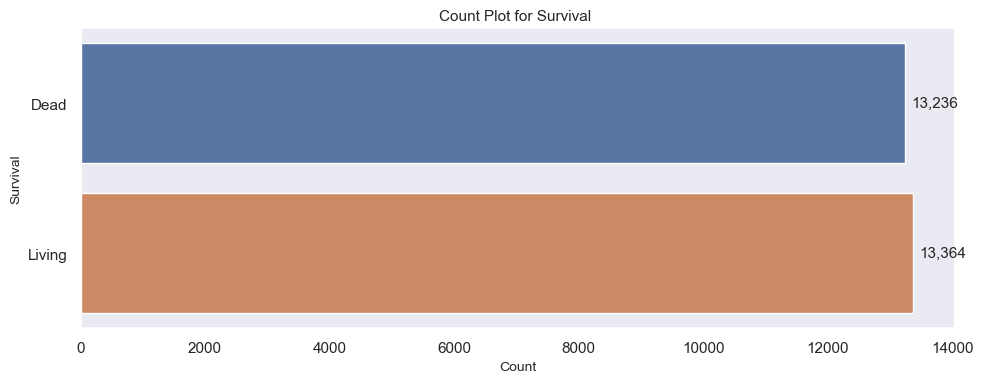

In [3]:
uv.countPlot(df, ['Survival'], figsize=(10, 4))

### Dummy Encoding

In [4]:
# encode
df_dummy = pd.get_dummies(df, columns=df_nominal.column.to_list(), drop_first=True)
# print shape
print(f"Shape: {df_dummy.shape}")
# add columns to list
dummyCols = df_dummy.columns.tolist()
# remove label
dummyCols.remove('Survival')
# create DataFrame
varDF = pd.DataFrame(columns=['ColumnName', 'Variance'])

Shape: (26600, 252)


In [5]:
for col in dummyCols:
    variance = df_dummy[col].var()
    # store the result
    result = {'ColumnName': col, 'Variance': variance}
    varDF.loc[len(varDF)] = result

varDF = varDF.sort_values(by='Variance', ascending=False)

In [6]:
lowVar = varDF.ColumnName[varDF.Variance < .01].to_list()
len(lowVar)

76

In [7]:
# encoded DataFrame
df_dummy = df_dummy.drop(columns=lowVar)
# print shape
print(f"Heart Dataset Rows: {df_dummy.shape[0]:,} & Columns: {df_dummy.shape[1]:,}")

Heart Dataset Rows: 26,600 & Columns: 176


### Split Dataset

In [8]:
from sklearn.model_selection import train_test_split

# split X & y
X = df_dummy.drop(columns = 'Survival')
y = df_dummy.Survival

# mapping values
y = y.map({'Dead': True, 'Living': False})

# split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

### Scale

In [9]:
from sklearn.preprocessing import MinMaxScaler

# initialize MinMaxScaler
scale = MinMaxScaler()

# fit
fitScale = scale.fit(X_train[df_ordinal.column.to_list()])

# transform
X_train[df_ordinal.column.to_list()] = fitScale.transform(X_train[df_ordinal.column.to_list()])
X_test[df_ordinal.column.to_list()] = fitScale.transform(X_test[df_ordinal.column.to_list()])

### RandomForestClassifier

In [10]:
from sklearn.ensemble import RandomForestClassifier
# function from sklearn.utils.class_weight computes the weights for each class to handle imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight

# the 'balanced' mode adjusts weights inversely proportional to class frequencies in the input data for Random Forest
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# grid search Hyperparameters Random Forest Classfiier
parameters = {
    'n_estimators': [100, 300, 500],
    'min_samples_split': [30, 40, 50],
    'min_samples_leaf': [8, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 7]
}


# Initialize Model with class weights
rfc_param = {'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate Random Forest Classifier
model = RandomForestClassifier(**rfc_param)

# CV with grid search for Hyper-Parameter tuning
rfc_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score = 'accuracy')

# best model
model = rfc_fit.best_estimator_

CV accuracy: 0.830 +/- 0.007


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [11]:
print(model)

RandomForestClassifier(class_weight={False: 0.995229632401085,
                                     True: 1.0048163188214185},
                       max_depth=7, min_samples_leaf=8, min_samples_split=40,
                       random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.91      0.85     10691
        True       0.89      0.76      0.82     10589

    accuracy                           0.83     21280
   macro avg       0.84      0.83      0.83     21280
weighted avg       0.84      0.83      0.83     21280



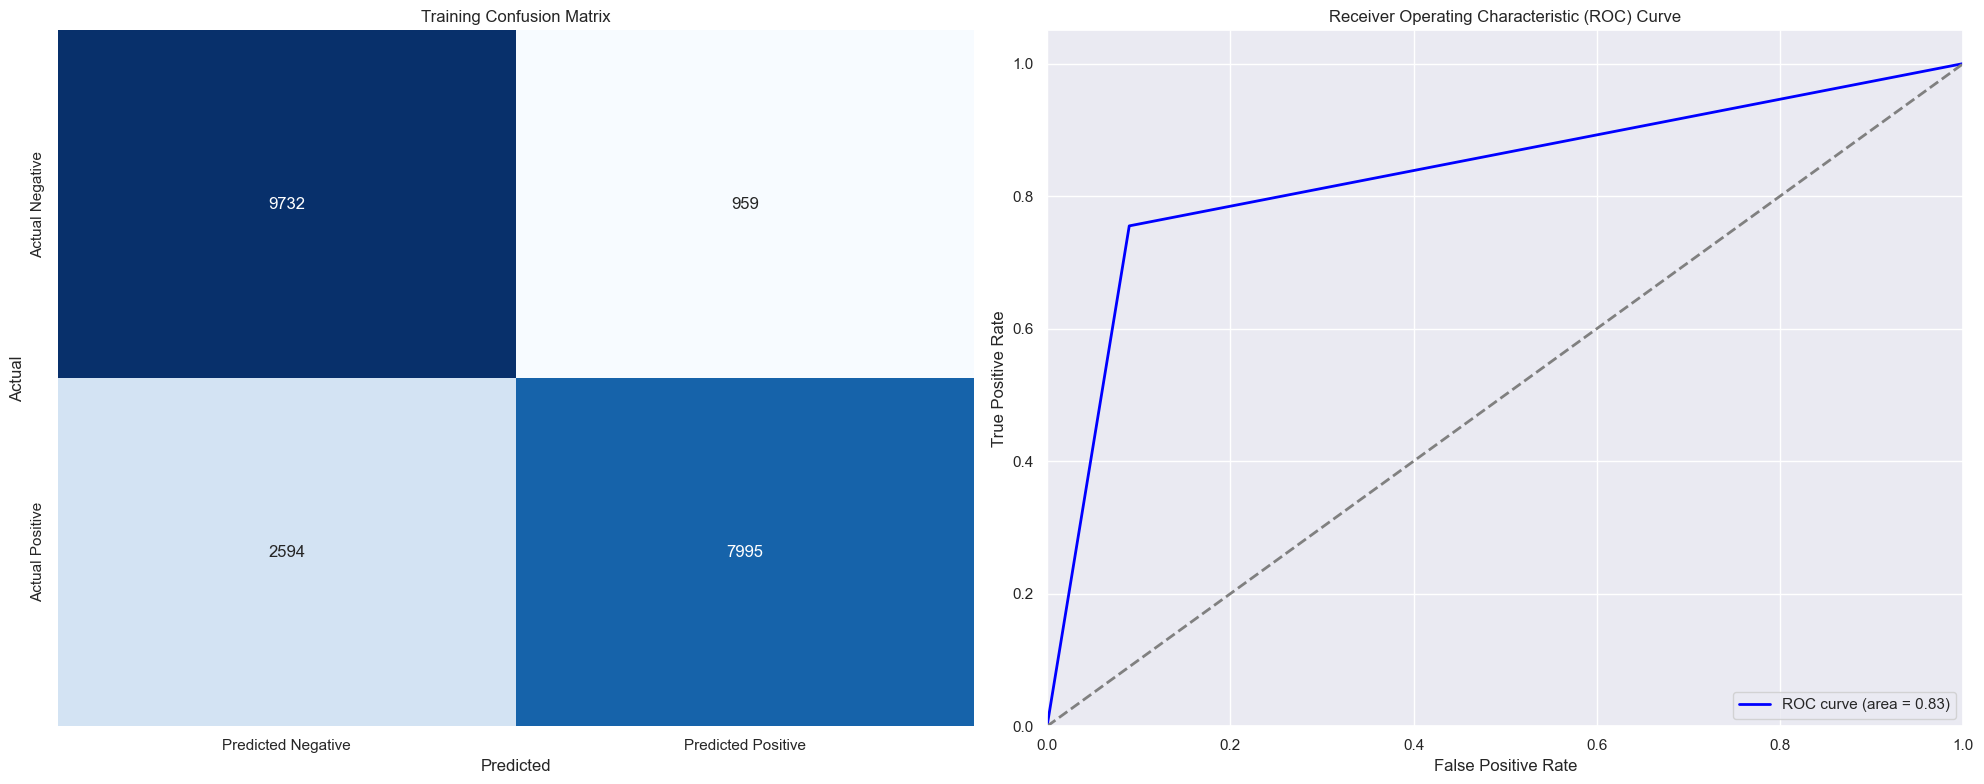

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664


In [12]:
# initialize variables
Algorithm = 'RandomForestClassifier'
Desc = 'RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed'
Model = 'rfc_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=None)
df_classfication

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.90      0.84      2673
        True       0.88      0.76      0.82      2647

    accuracy                           0.83      5320
   macro avg       0.84      0.83      0.83      5320
weighted avg       0.84      0.83      0.83      5320



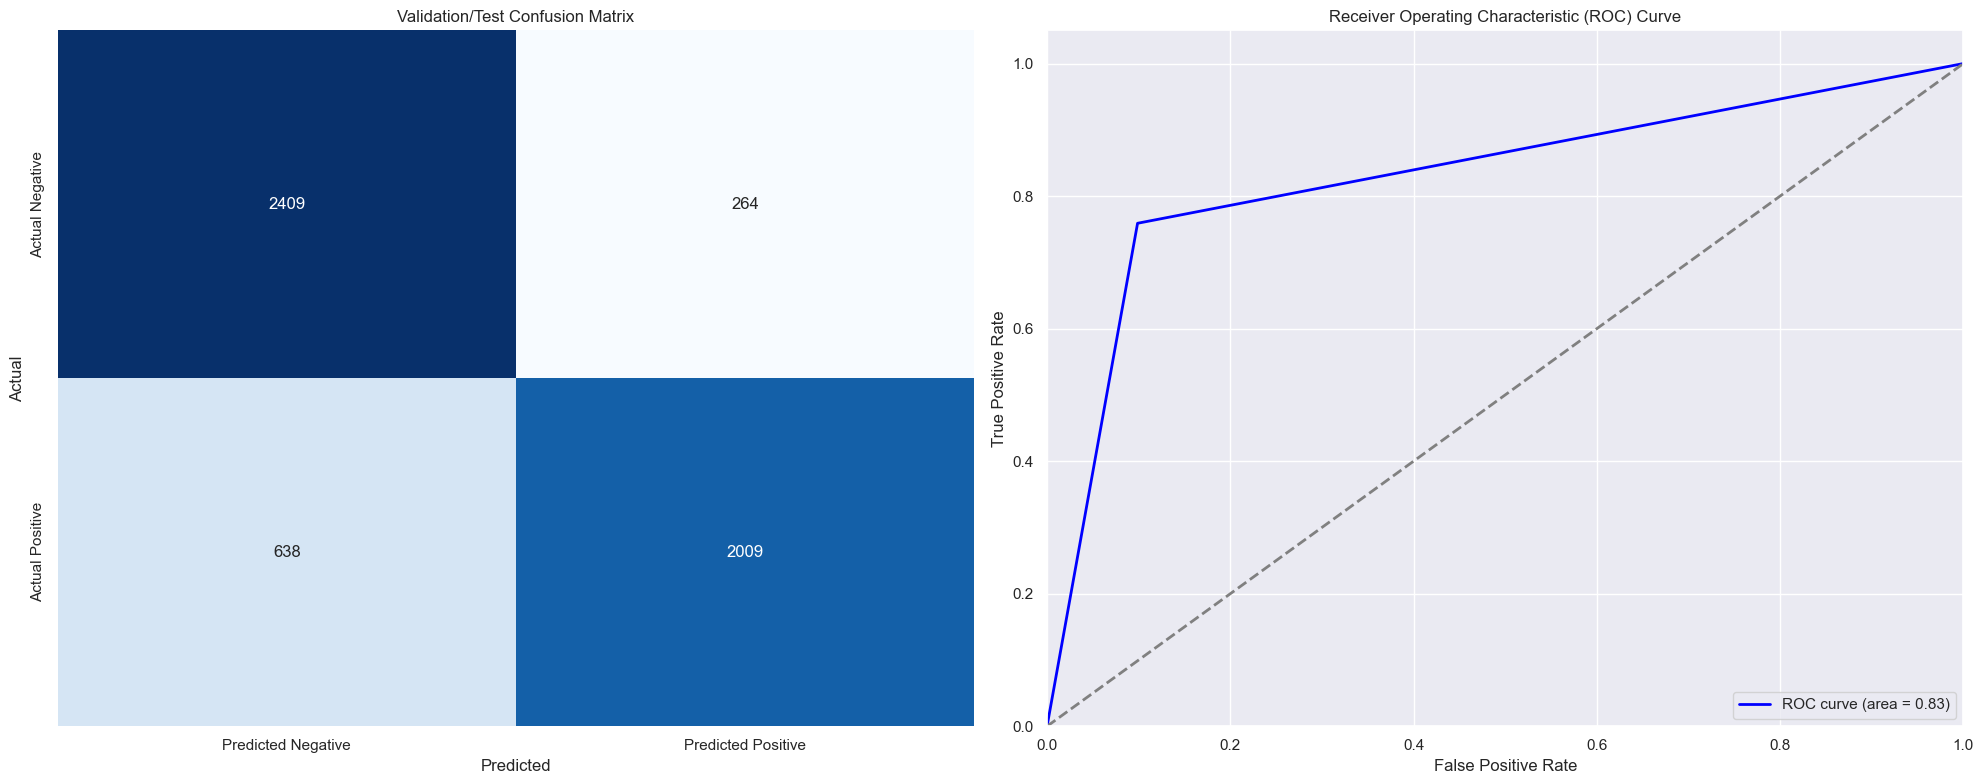

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103


In [13]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, df_classfication)
df_classfication

#### Feature Importance

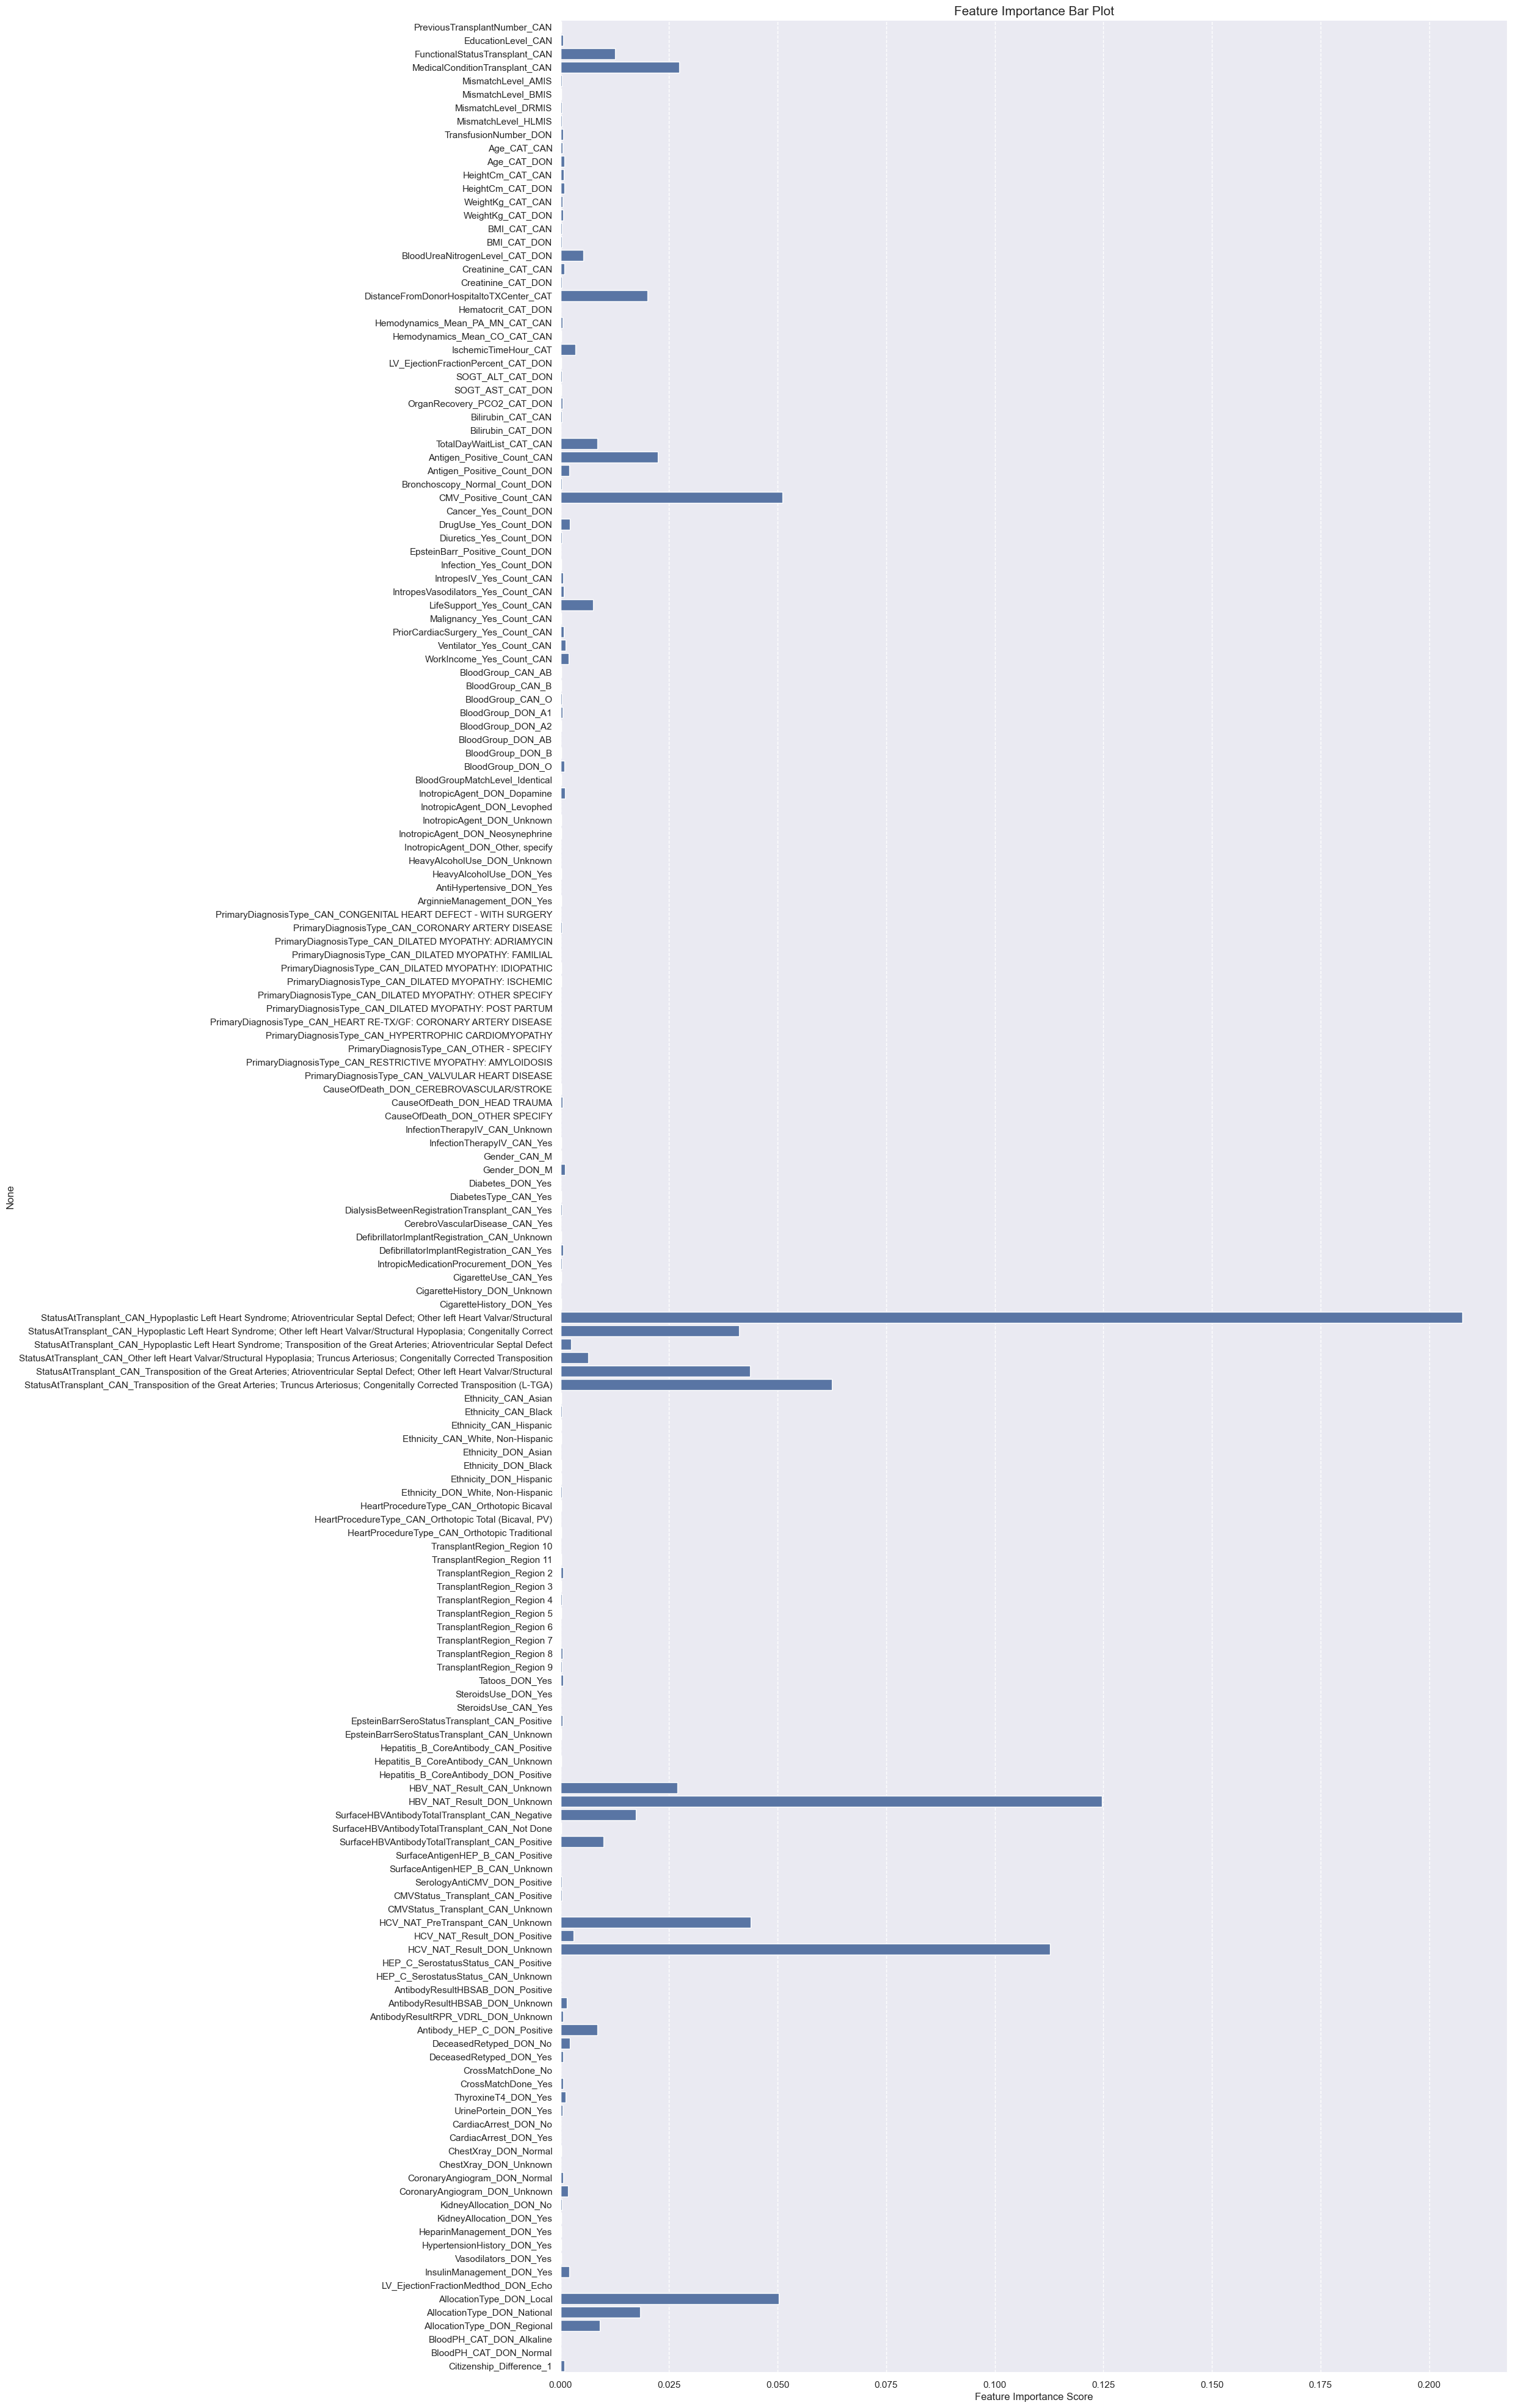

In [14]:
df_rfc = umf.plotFeatureImportance(model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [15]:
df_rfc.sort_values(by='Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.207602
HBV_NAT_Result_DON_Unknown,0.124592
HCV_NAT_Result_DON_Unknown,0.112759
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.062452
CMV_Positive_Count_CAN,0.051098
AllocationType_DON_Local,0.050315
HCV_NAT_PreTranspant_CAN_Unknown,0.043845
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.043658
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.041150
MedicalConditionTransplant_CAN,0.027384


### LogisticRegression

In [16]:
# import library
from sklearn.linear_model import LogisticRegression

# define the hyperparameter grid to search
parameters = dict(
C = list(np.round(np.linspace(0.01, 5, 20),2))
)

# Base Model
lrc_param = {'max_iter':10000, 'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# instantiate LogisticRegression Classifier
model = LogisticRegression(**lrc_param)

# CV with grid search for Hyper-Parameter tuning
lrc_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
model = lrc_fit.best_estimator_

CV accuracy: 0.843 +/- 0.006


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [17]:
print(model)

LogisticRegression(C=2.11,
                   class_weight={False: 0.995229632401085,
                                 True: 1.0048163188214185},
                   max_iter=10000, random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.78      0.96      0.86     10691
        True       0.95      0.73      0.82     10589

    accuracy                           0.85     21280
   macro avg       0.87      0.84      0.84     21280
weighted avg       0.87      0.85      0.84     21280



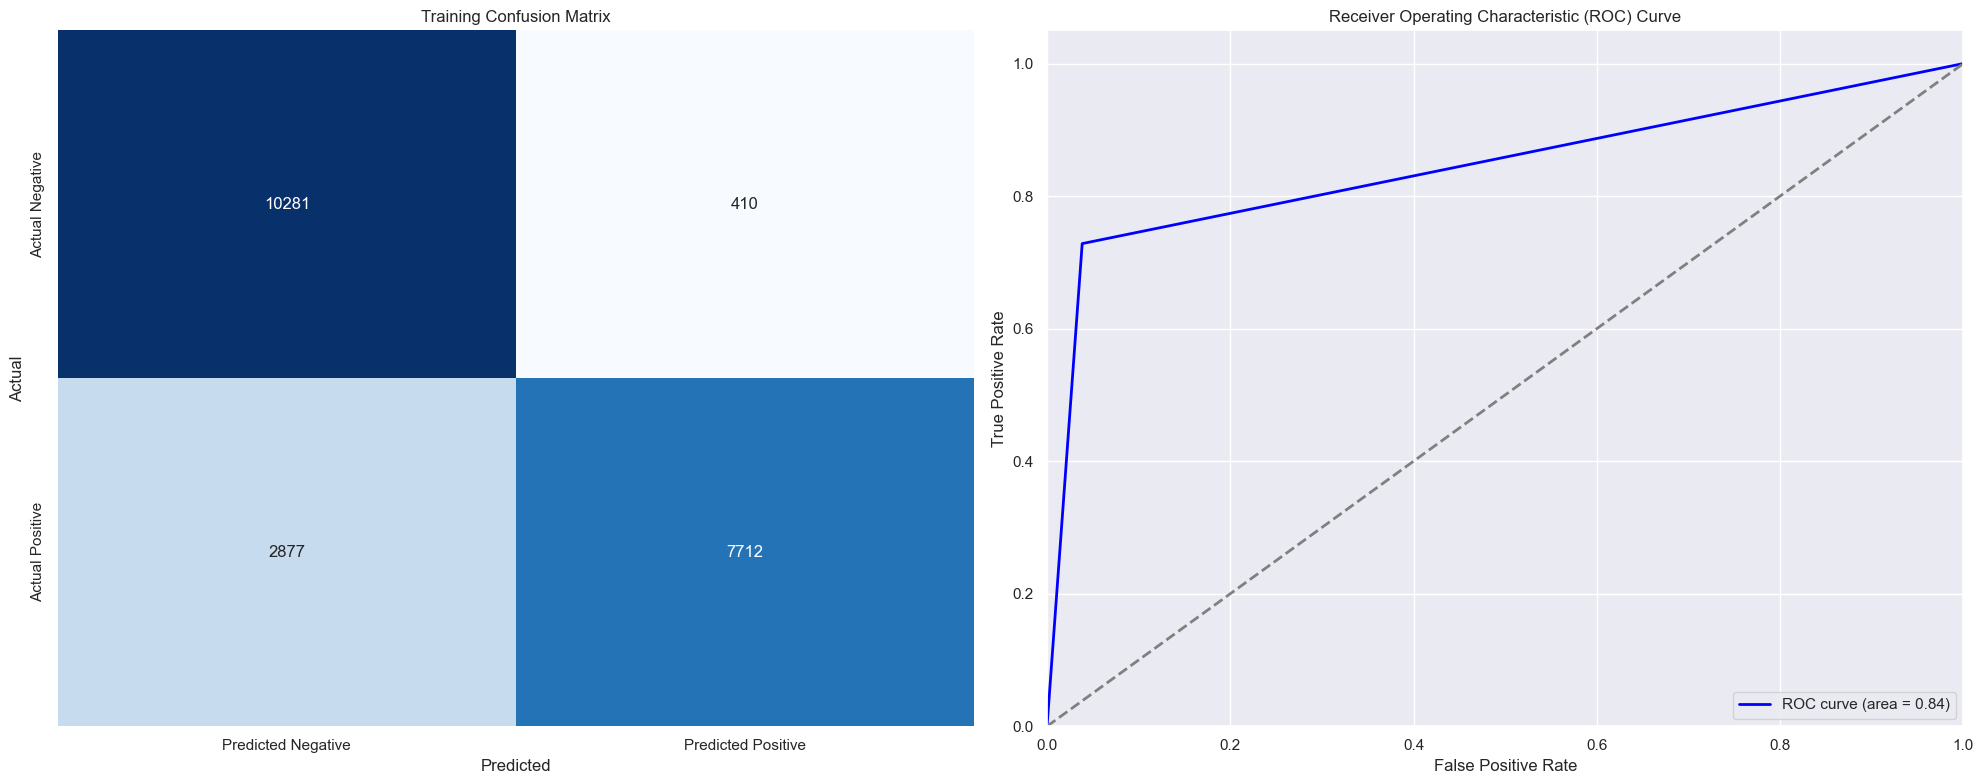

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976


In [18]:
# initialize variables
Algorithm = 'LogisticRegression'
Desc = 'LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed'
Model = 'lrc_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.96      0.87      2673
        True       0.95      0.74      0.83      2647

    accuracy                           0.85      5320
   macro avg       0.87      0.85      0.85      5320
weighted avg       0.87      0.85      0.85      5320



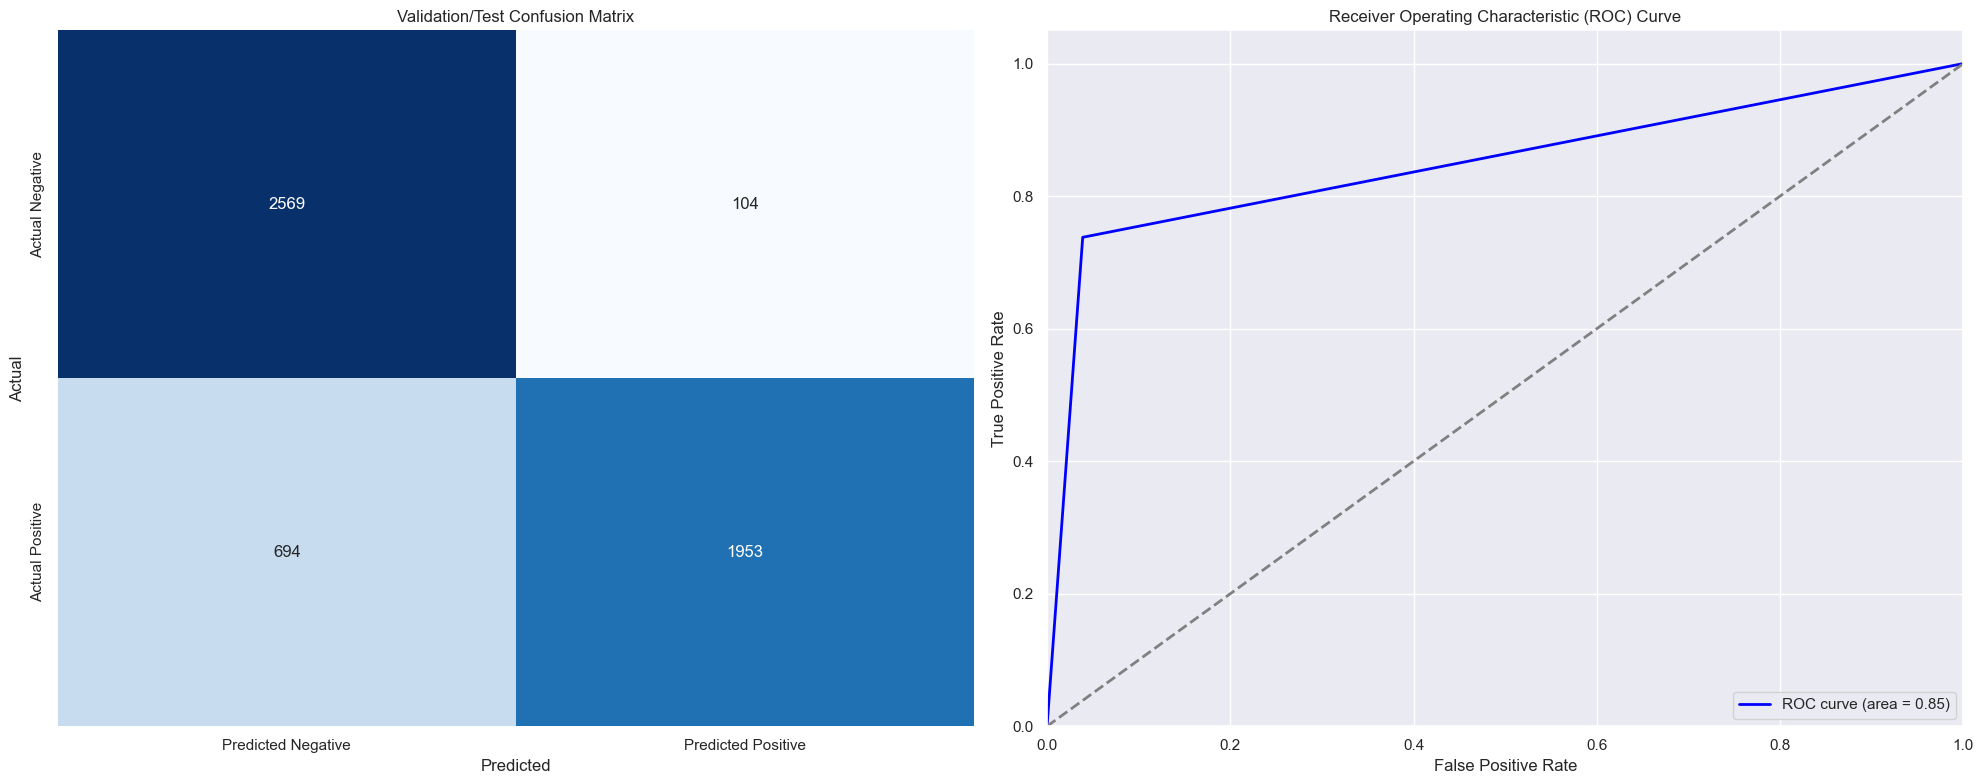

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454


In [19]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

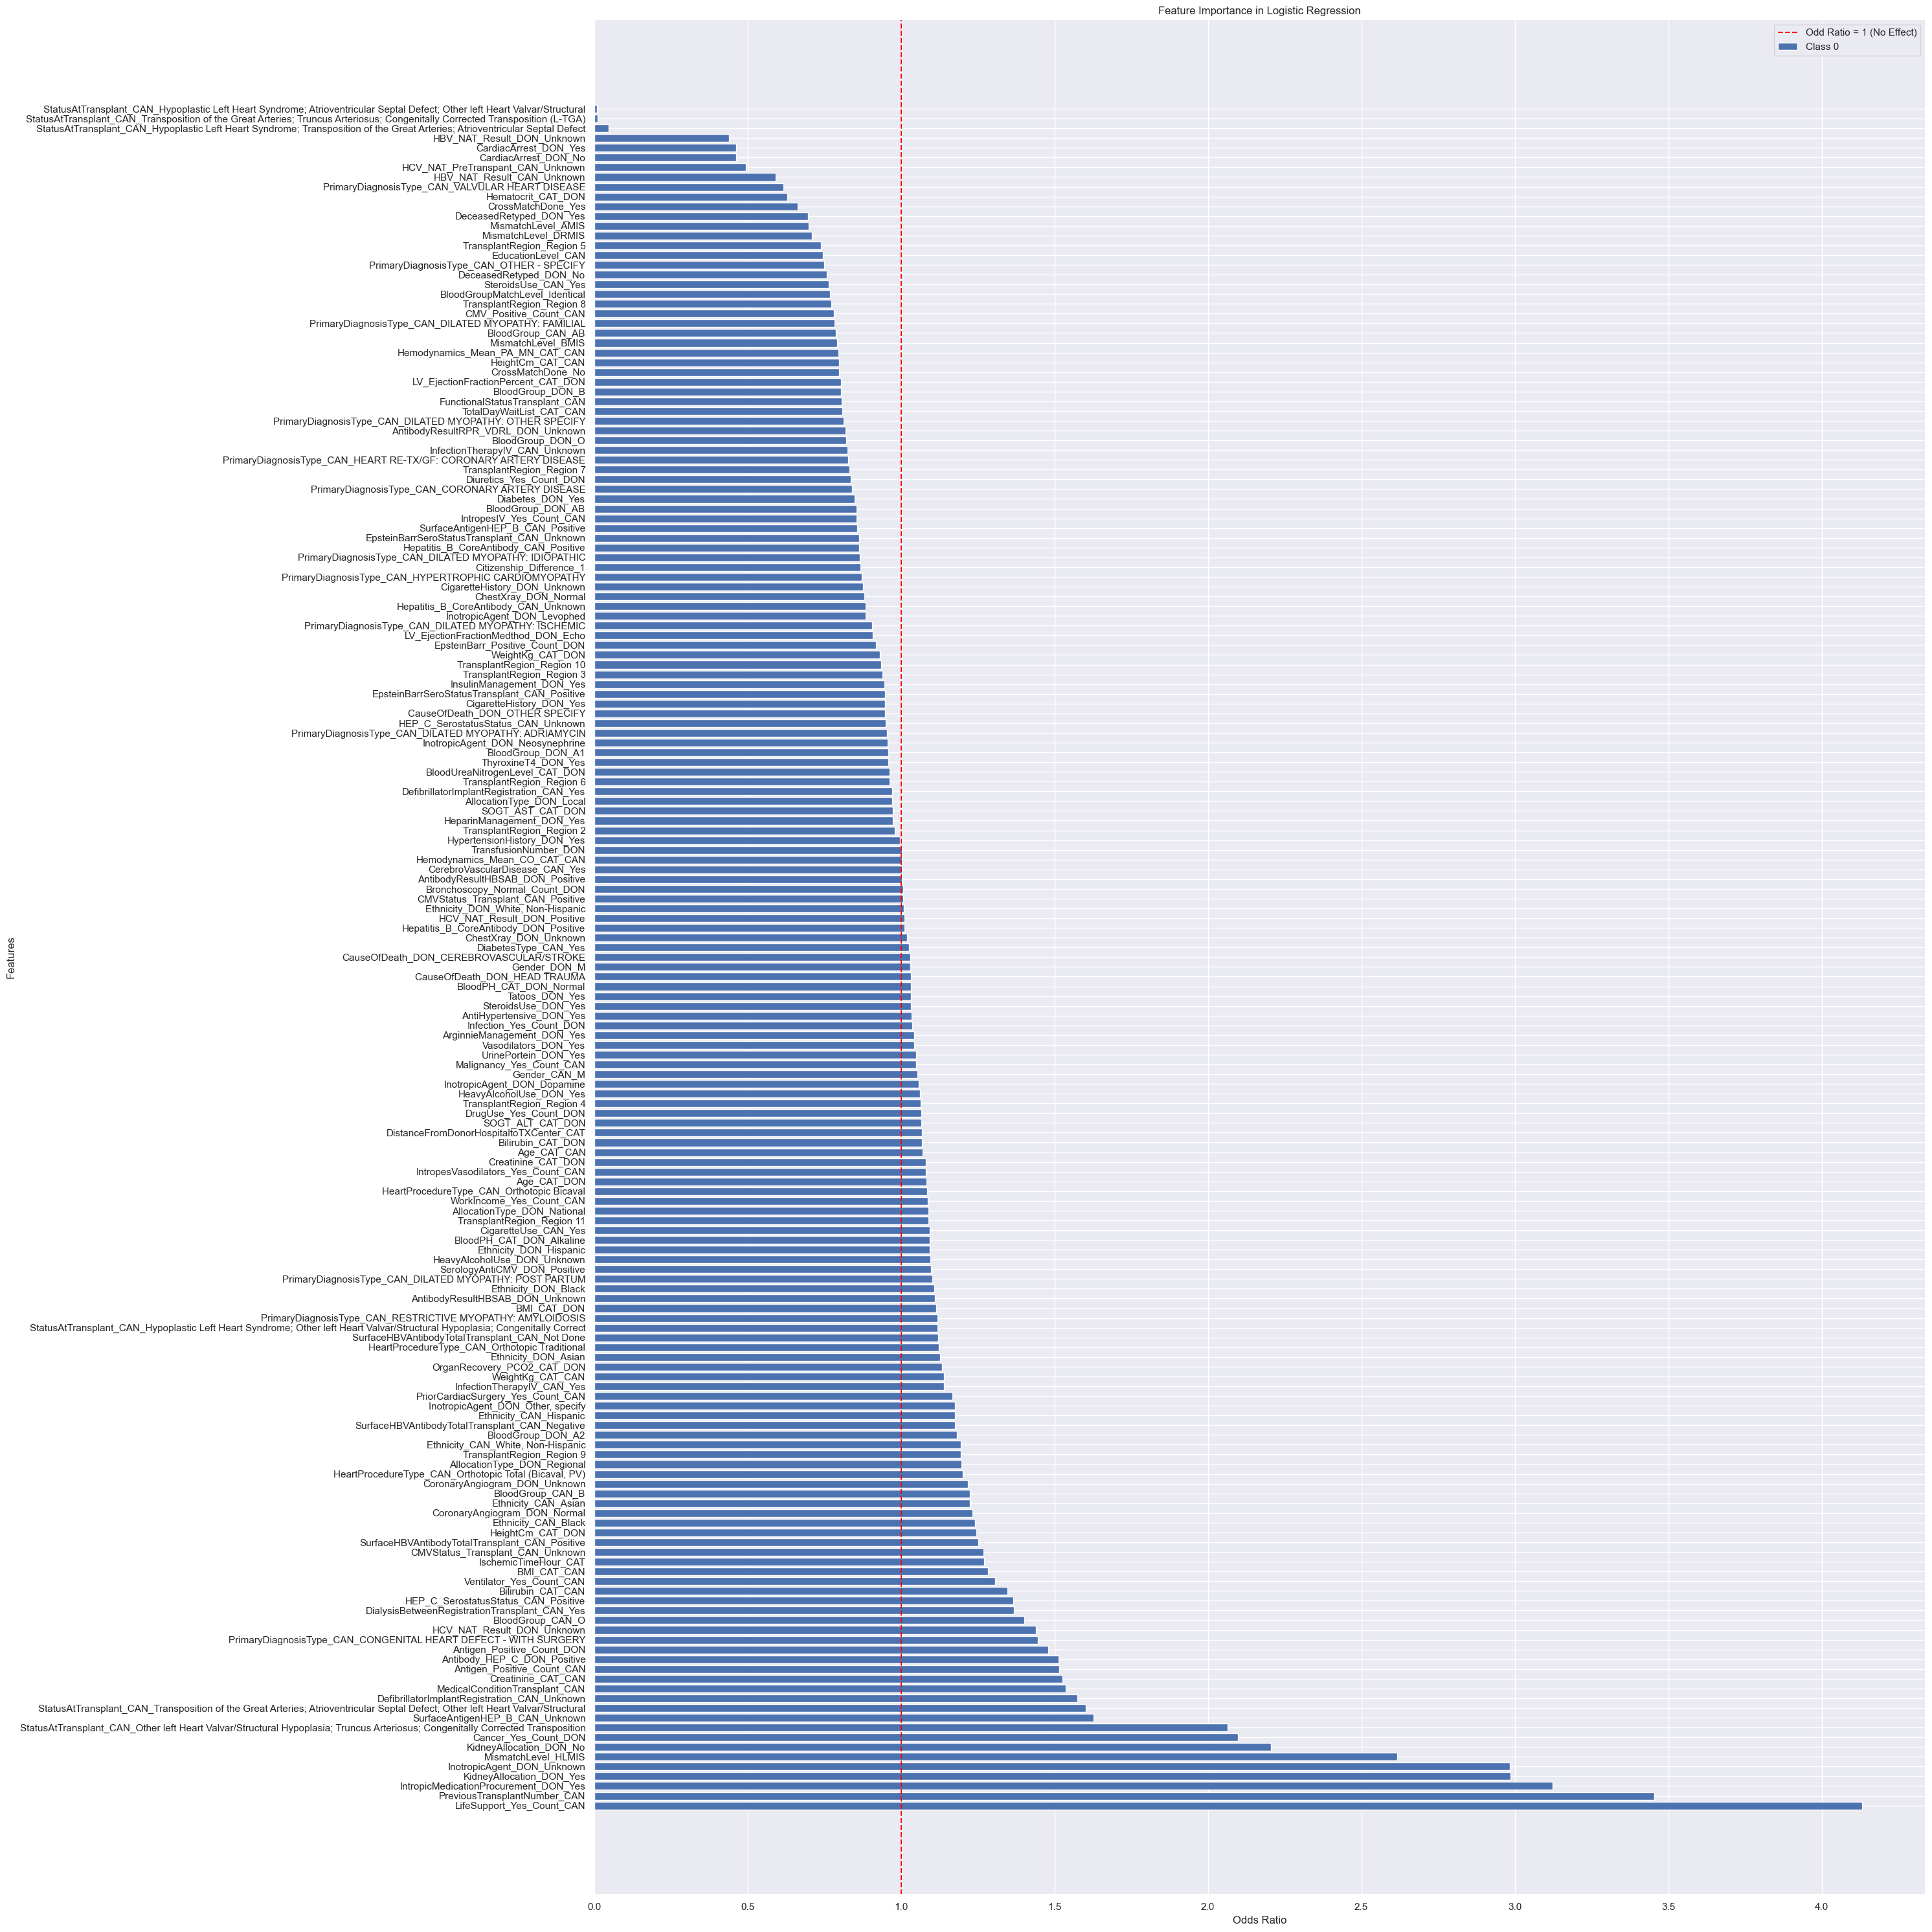

In [20]:
df_lrc = umf.LogisticFeatureImportance(model, figsize=(30,30), fontsize=6)

In [21]:
df_lrc.sort_values(by='Coefficient', ascending=False).head(20)

,Feature,Coefficient,Description,Odd Ratio,Percentage Change in Odds,Probability,Class
0,LifeSupport_Yes_Count_CAN,1.418682,Increase in the log-odds of the Positive Class,4.131671,313.167146,0.805132,Class 0
1,PreviousTransplantNumber_CAN,1.239396,Increase in the log-odds of the Positive Class,3.453526,245.352647,0.775459,Class 0
2,IntropicMedicationProcurement_DON_Yes,1.138739,Increase in the log-odds of the Positive Class,3.122828,212.282775,0.757448,Class 0
3,KidneyAllocation_DON_Yes,1.093946,Increase in the log-odds of the Positive Class,2.986034,198.603355,0.749124,Class 0
4,InotropicAgent_DON_Unknown,1.092938,Increase in the log-odds of the Positive Class,2.983024,198.302430,0.748934,Class 0
5,MismatchLevel_HLMIS,0.961566,Increase in the log-odds of the Positive Class,2.615790,161.578993,0.723435,Class 0
6,KidneyAllocation_DON_No,0.791208,Increase in the log-odds of the Positive Class,2.206060,120.605958,0.688091,Class 0
7,Cancer_Yes_Count_DON,0.741170,Increase in the log-odds of the Positive Class,2.098388,109.838847,0.677252,Class 0
8,StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition,0.724587,Increase in the log-odds of the Positive Class,2.063879,106.387856,0.673616,Class 0
9,SurfaceAntigenHEP_B_CAN_Unknown,0.486755,Increase in the log-odds of the Positive Class,1.627028,62.702835,0.619342,Class 0


### XGBClassifier

#### Explanation of the Gamma Parameter
- In XGBoost, the regularization term that controls the minimum loss reduction required to make a split at a node is known as the "gamma" parameter. This parameter plays a crucial role in the decision-making process of the algorithm during the tree construction phase.
- Definition: The gamma parameter specifies the minimum loss reduction required to make a further partition on a leaf node of the tree. If the reduction in loss from making a split is less than gamma, then that split will not be made.
- Purpose: By setting a higher value for gamma, you can prevent overfitting by making the model more conservative. It effectively controls how complex the model can become by limiting the number of splits. A lower gamma allows more splits and can lead to a more complex model.
- Impact on Model Complexity:
    - High Gamma Value: Results in fewer splits, leading to simpler trees that may underfit the data.
    - Low Gamma Value: Allows more splits, potentially leading to more complex trees that may overfit the training data.

The gamma parameter is essential for controlling the complexity of models built using XGBoost by regulating how much improvement in loss is necessary for splitting nodes. Adjusting this parameter can help balance between bias and variance, thus improving model performance on unseen data.

In [22]:
# import library
from xgboost import XGBClassifier

# calculate the scale_pos_weight to adjust for class imbalance
# helps to counteract the imbalance by giving more weight to the minority class (usually the positive class in binary classification).
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# define the hyperparameter grid to search
parameters = dict(
n_estimators = [50, 100, 200],
max_depth = [3, 5],
learning_rate = [0.01, 0.05, 0.1],
subsample = [0.4, 0.7],
gamma = [0.8, 1, 5]   # regularization term that controls the minimum loss reduction required to make a split at a node.
)

# Base Model
xgb_param = {'scale_pos_weight': scale_pos_weight, 'random_state': RANDOM_STATE}

# instantiate XGB Classifier
model = XGBClassifier(**xgb_param)

# CV with grid search for Hyper-Parameter tuning
xgb_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nSplit=5, score='accuracy')

# best model
model = xgb_fit.best_estimator_

CV accuracy: 0.845 +/- 0.007


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [23]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.8, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=1776, ...)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.98      0.88     10691
        True       0.98      0.74      0.84     10589

    accuracy                           0.86     21280
   macro avg       0.88      0.86      0.86     21280
weighted avg       0.88      0.86      0.86     21280



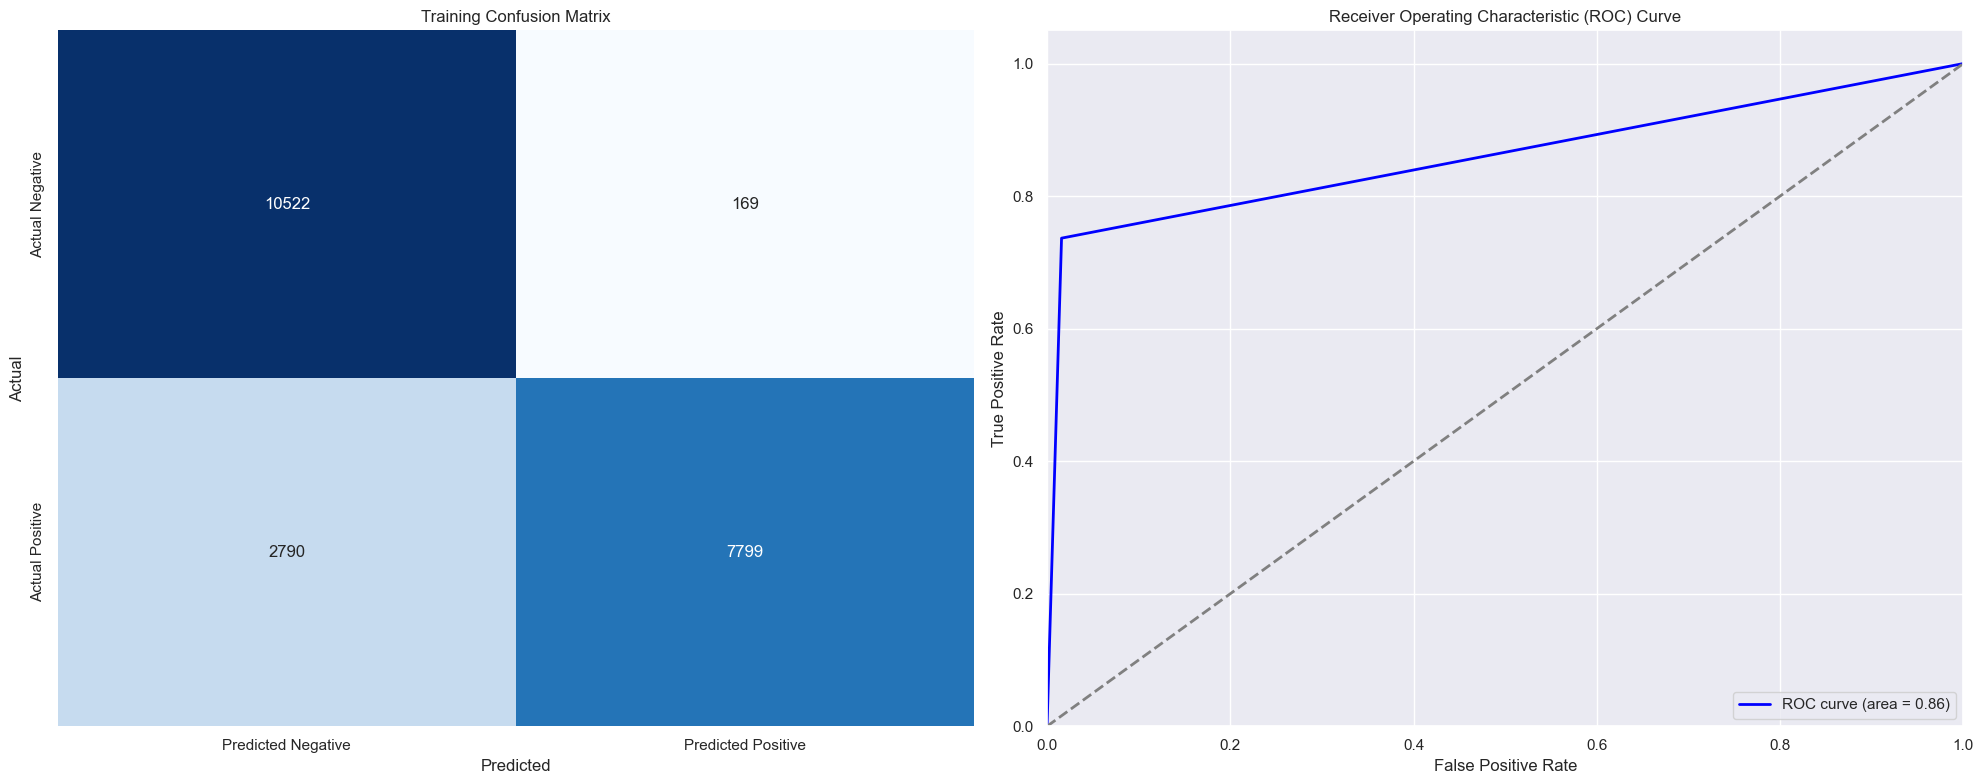

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356


In [24]:
# initialize variables
Algorithm = 'XGBClassifier'
Desc = 'XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed'
Model = 'xgb_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.78      0.97      0.87      2673
        True       0.96      0.73      0.83      2647

    accuracy                           0.85      5320
   macro avg       0.87      0.85      0.85      5320
weighted avg       0.87      0.85      0.85      5320



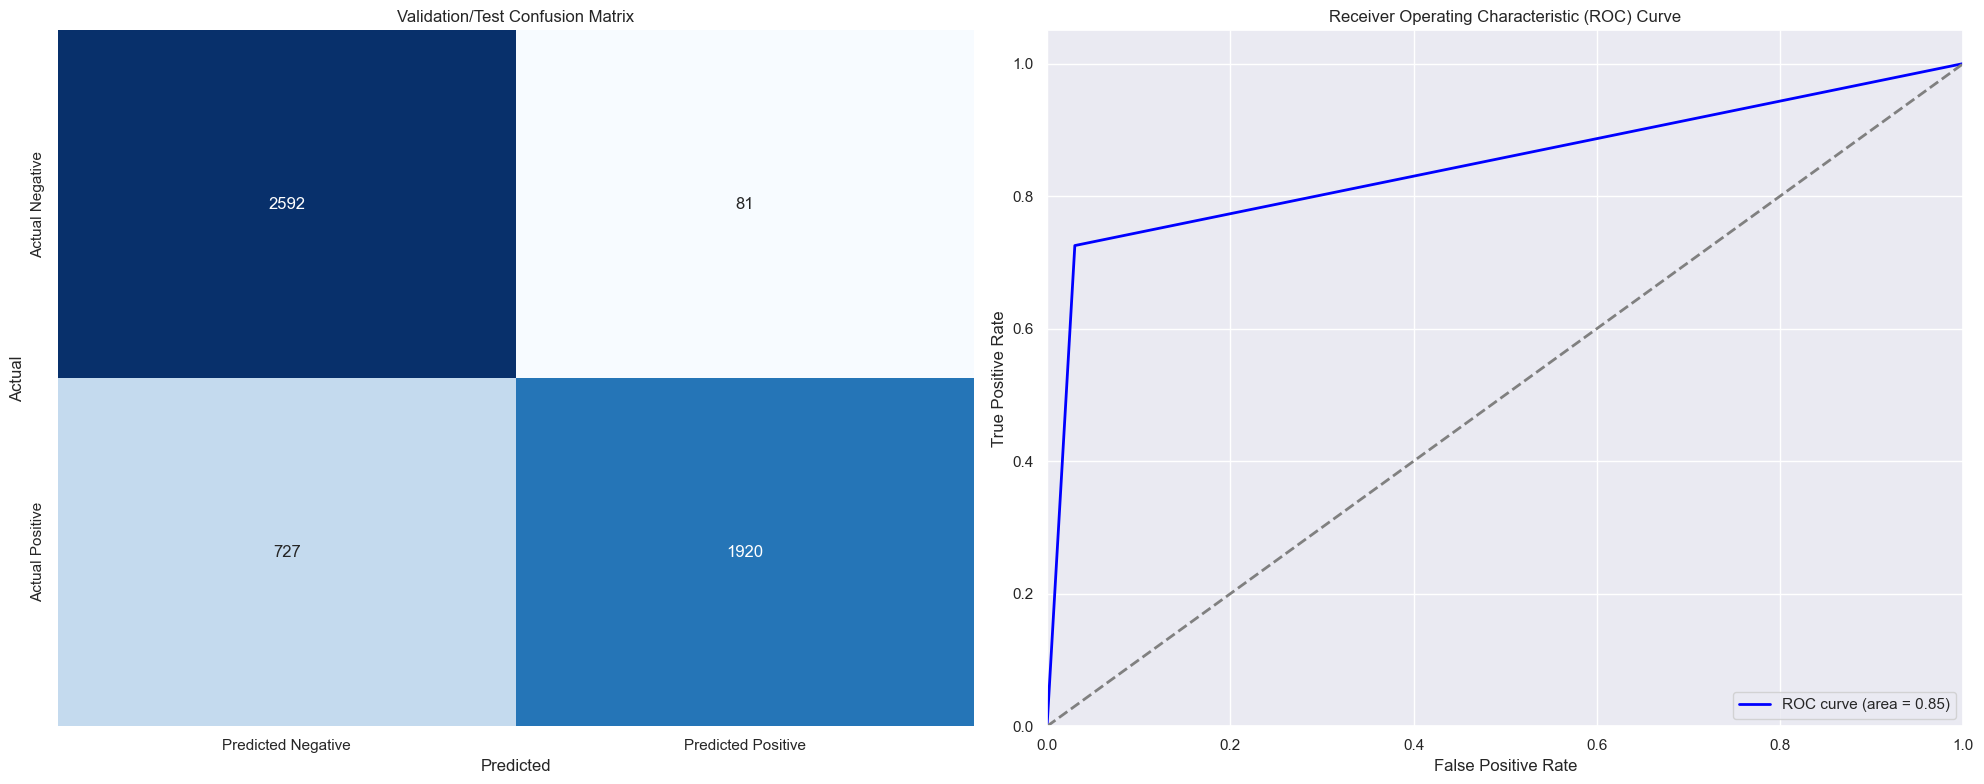

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523


In [25]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

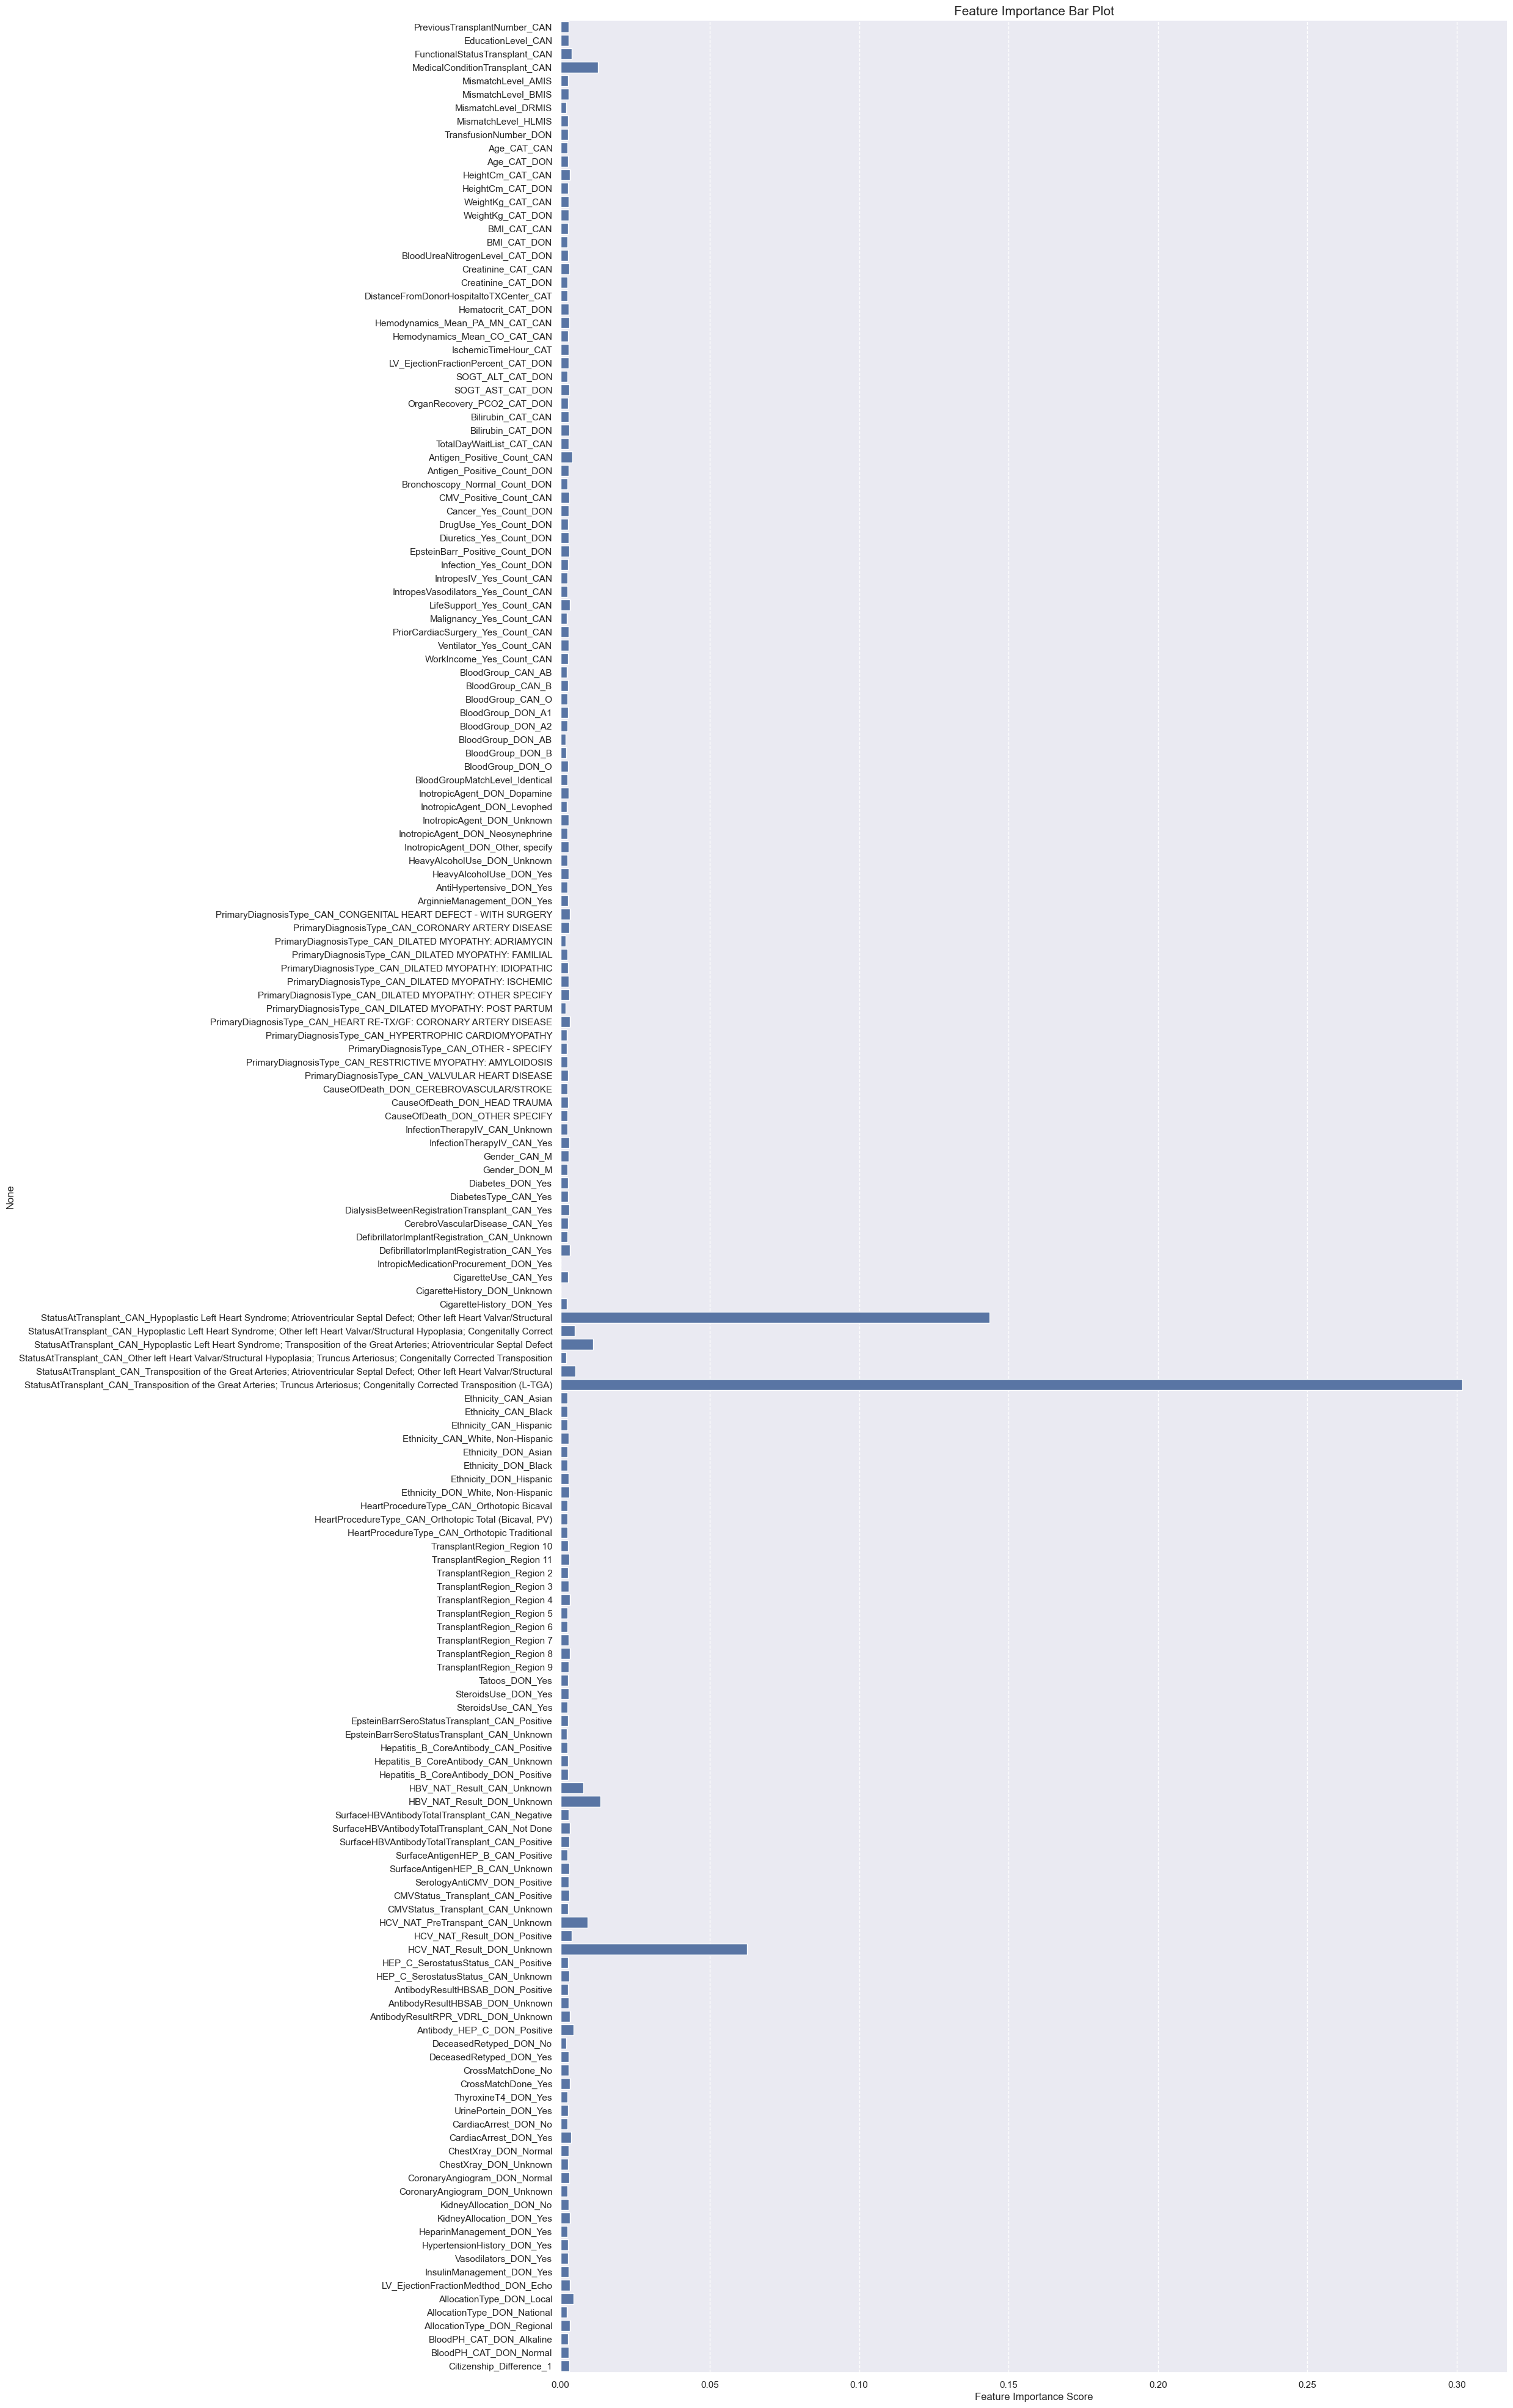

In [26]:
df_xgb = umf.plotFeatureImportance(model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [27]:
df_xgb.sort_values(by = 'Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.301832
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.143675
HCV_NAT_Result_DON_Unknown,0.062363
HBV_NAT_Result_DON_Unknown,0.013382
MedicalConditionTransplant_CAN,0.012618
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,0.010884
HCV_NAT_PreTranspant_CAN_Unknown,0.009022
HBV_NAT_Result_CAN_Unknown,0.007728
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.004936
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.004823


### KNN
- `K-Nearest Neighbors (KNN)`
    - Type: Instance-based learning (lazy learning)
    - Mechanism: Classifies a data point based on the majority class among its k-nearest neighbors.
    - Pros: Simple, intuitive, no training phase.
    - Cons: Computationally expensive during prediction, sensitive to irrelevant features and the choice of k.

In [28]:
# import library
from sklearn.neighbors import KNeighborsClassifier

# define the parameter grid for GridSearchCV
parameters = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'leaf_size': [10, 30, 50]
}

# create a KNN model
model = KNeighborsClassifier()

# CV with grid search for Hyper-Parameter tuning
knn_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nSplit=5, score='accuracy')

# best model
model = knn_fit.best_estimator_

CV accuracy: 0.773 +/- 0.009


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [29]:
print(model)

KNeighborsClassifier(leaf_size=10, metric='manhattan', n_neighbors=7)


#### Metrics

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.80      0.90      0.84     10691
        True       0.88      0.77      0.82     10589

    accuracy                           0.83     21280
   macro avg       0.84      0.83      0.83     21280
weighted avg       0.84      0.83      0.83     21280



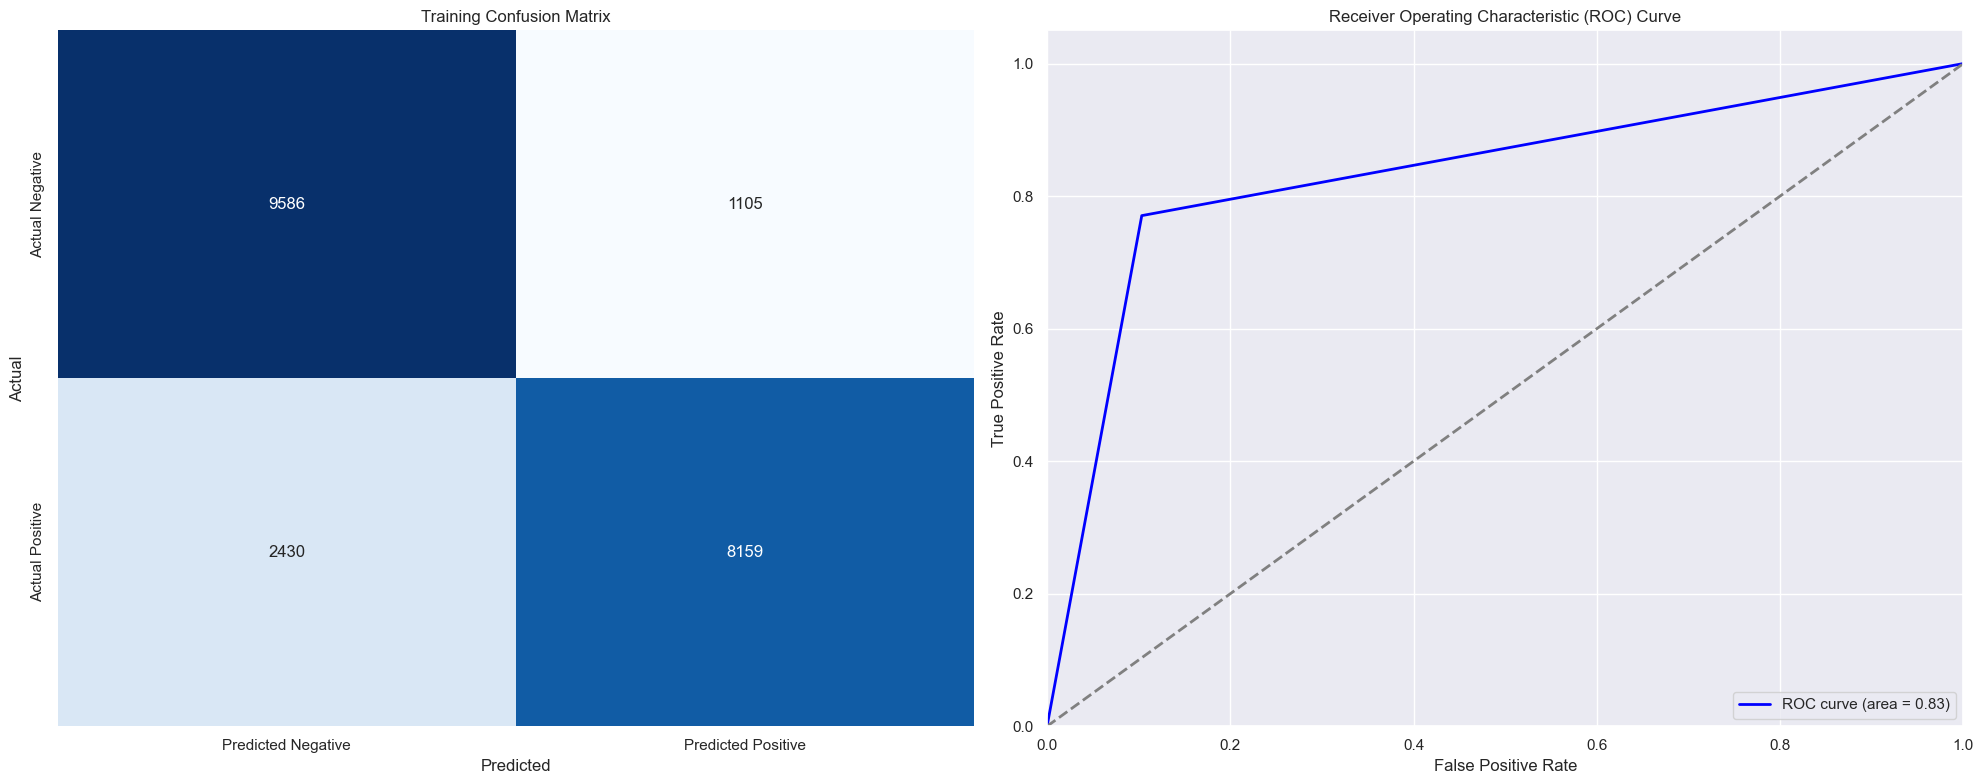

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579


In [30]:
# initialize variables
Algorithm = 'KNN'
Desc = 'KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed'
Model = 'knn_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.74      0.85      0.79      2673
        True       0.82      0.71      0.76      2647

    accuracy                           0.78      5320
   macro avg       0.78      0.78      0.78      5320
weighted avg       0.78      0.78      0.78      5320



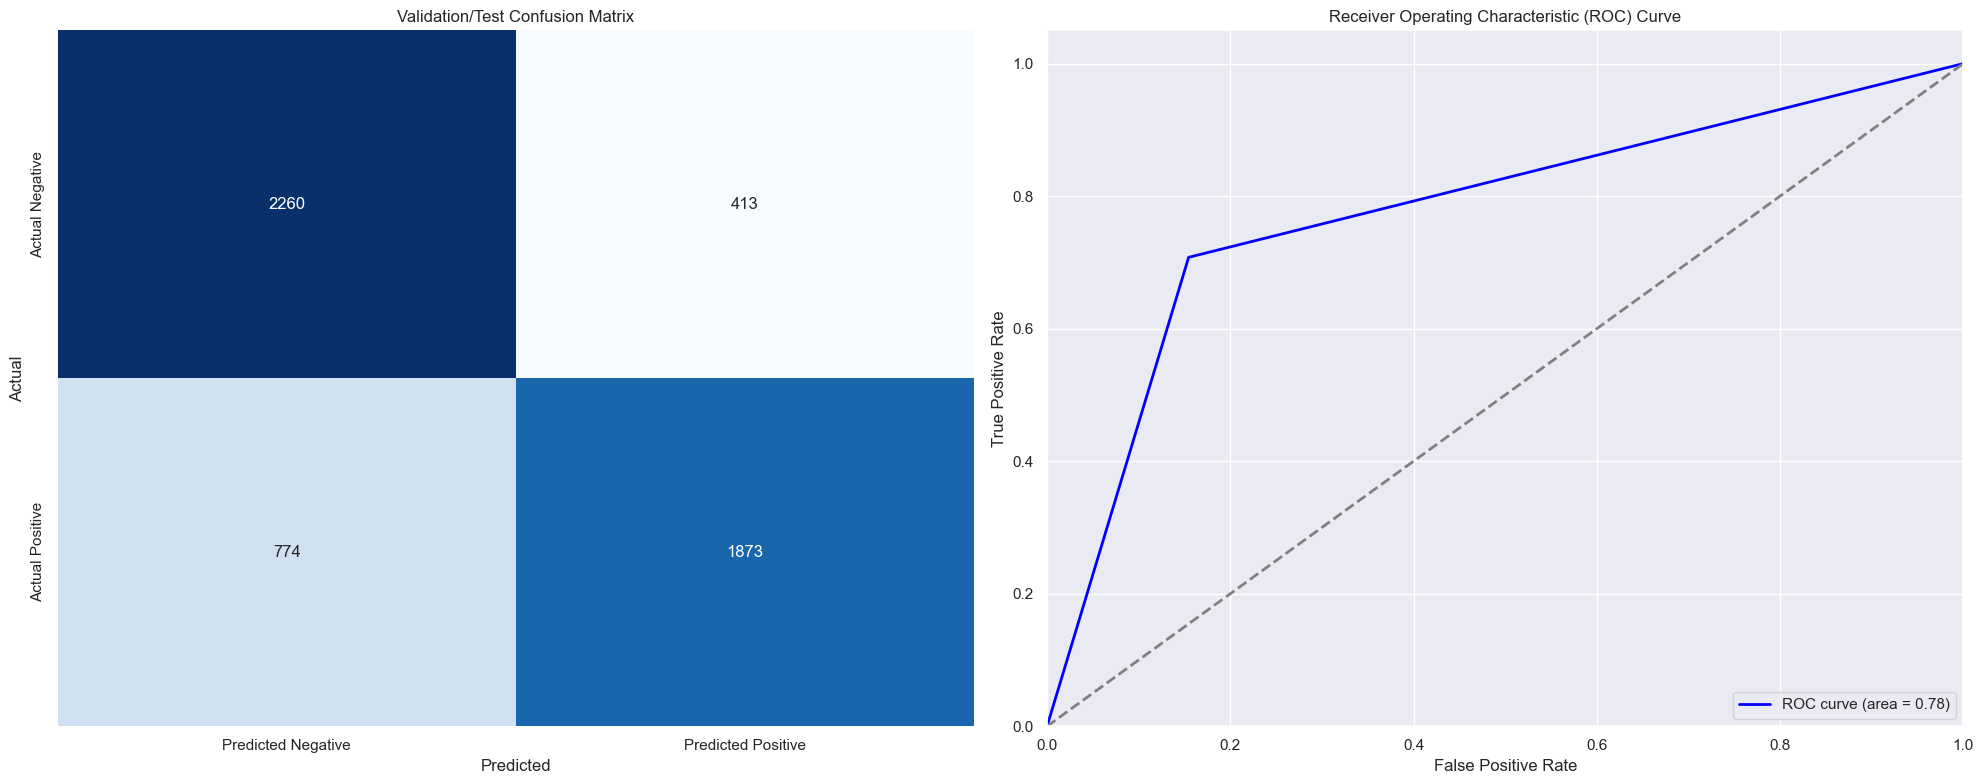

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579
7,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.776880,0.707594,0.759376,0.725245,0.819335,0.845492,0.776543


In [31]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

### AdaBoostClassifier

In [32]:
# import library
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# define the parameter grid for GridSearchCV
parameters = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 1.0]
}
# base estimater
estimator = DecisionTreeClassifier(max_depth=1)

# create a AdaBoost model
model = AdaBoostClassifier(estimator=estimator, algorithm='SAMME', random_state=RANDOM_STATE)

# CV with grid search for Hyper-Parameter tuning
ada_fit = umf.stratified_grid(model, parameters, X_train, y_train, seed=RANDOM_STATE, nSplit=5, score='accuracy')

# best model
model = ada_fit.best_estimator_

CV accuracy: 0.841 +/- 0.007


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [33]:
print(model)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=200, random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.78      0.96      0.86     10691
        True       0.95      0.72      0.82     10589

    accuracy                           0.84     21280
   macro avg       0.86      0.84      0.84     21280
weighted avg       0.86      0.84      0.84     21280



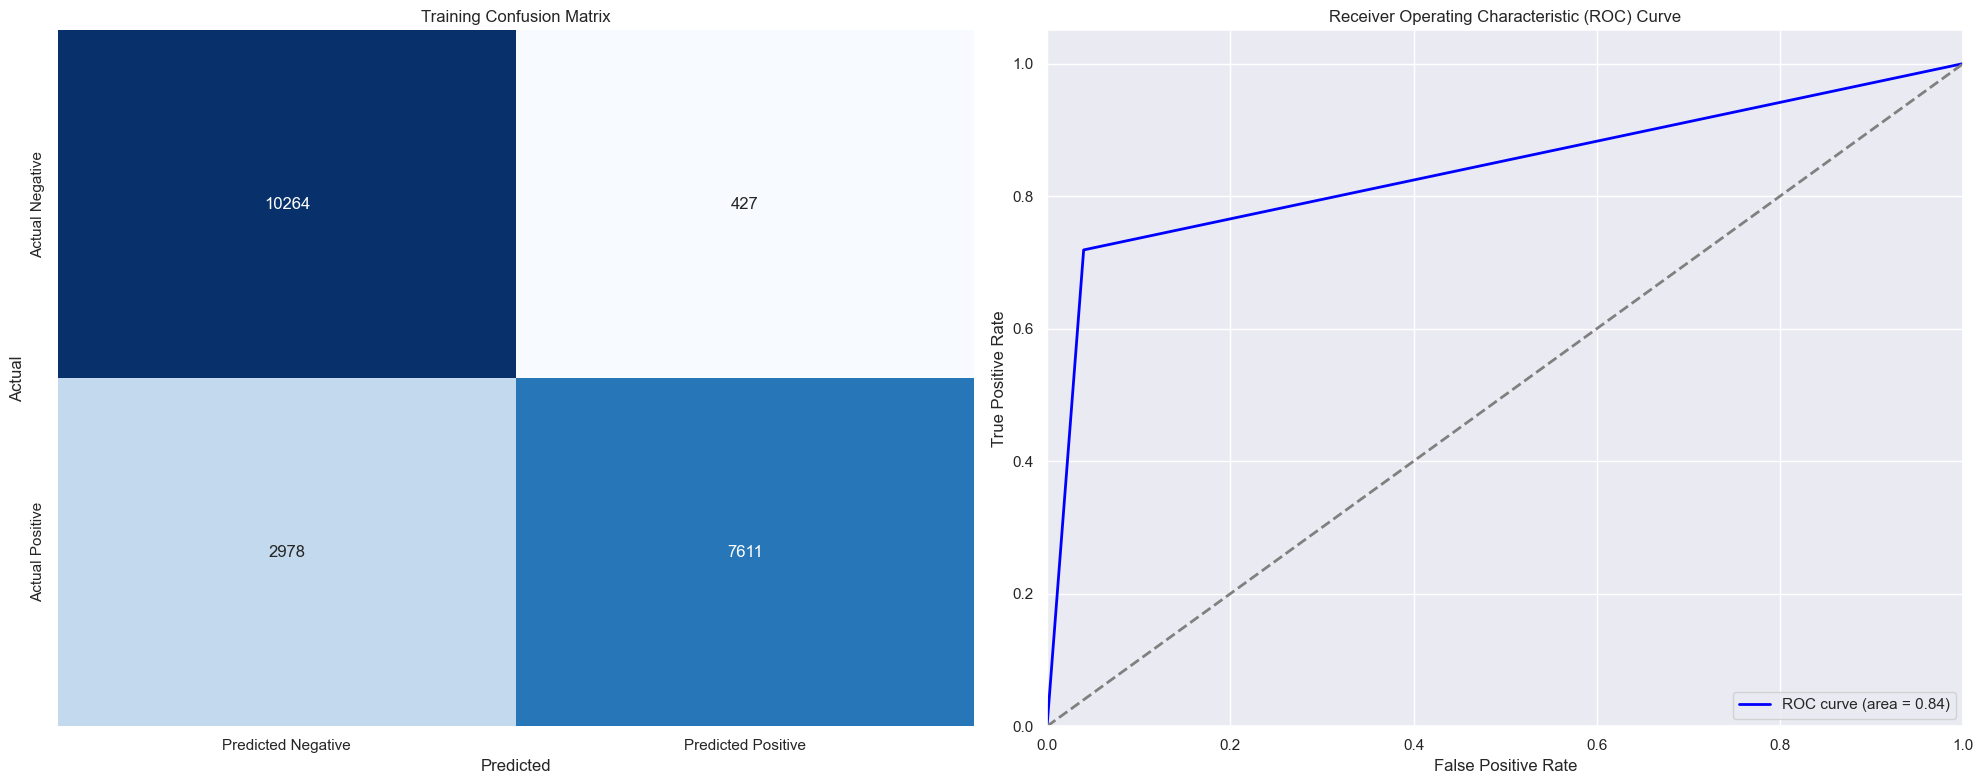

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579
7,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.776880,0.707594,0.759376,0.725245,0.819335,0.845492,0.776543
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.839991,0.718765,0.817201,0.820526,0.946877,0.960060,0.839412


In [34]:
# initialize variables
Algorithm = 'AdaBoost'
Desc = 'AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed'
Model = 'ada_fit'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.78      0.96      0.86      2673
        True       0.95      0.73      0.82      2647

    accuracy                           0.84      5320
   macro avg       0.86      0.84      0.84      5320
weighted avg       0.86      0.84      0.84      5320



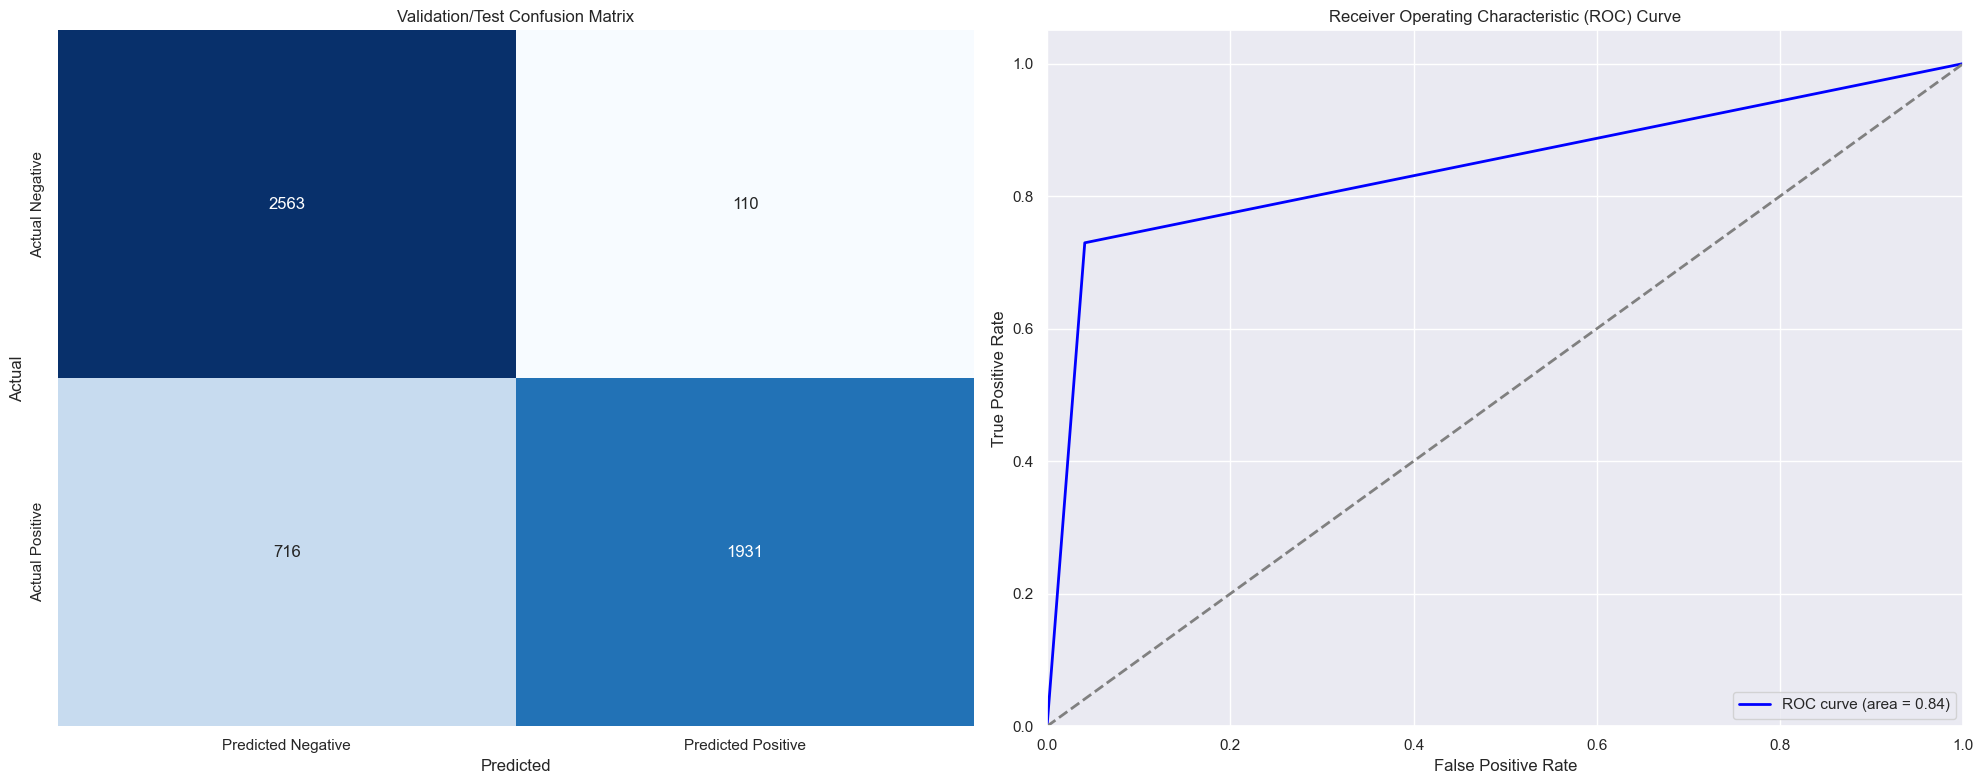

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579
7,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.776880,0.707594,0.759376,0.725245,0.819335,0.845492,0.776543
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.839991,0.718765,0.817201,0.820526,0.946877,0.960060,0.839412
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.844737,0.729505,0.823805,0.824775,0.946105,0.958848,0.844176


In [35]:
# initialize variable
Type = 'Validation/Test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, model, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

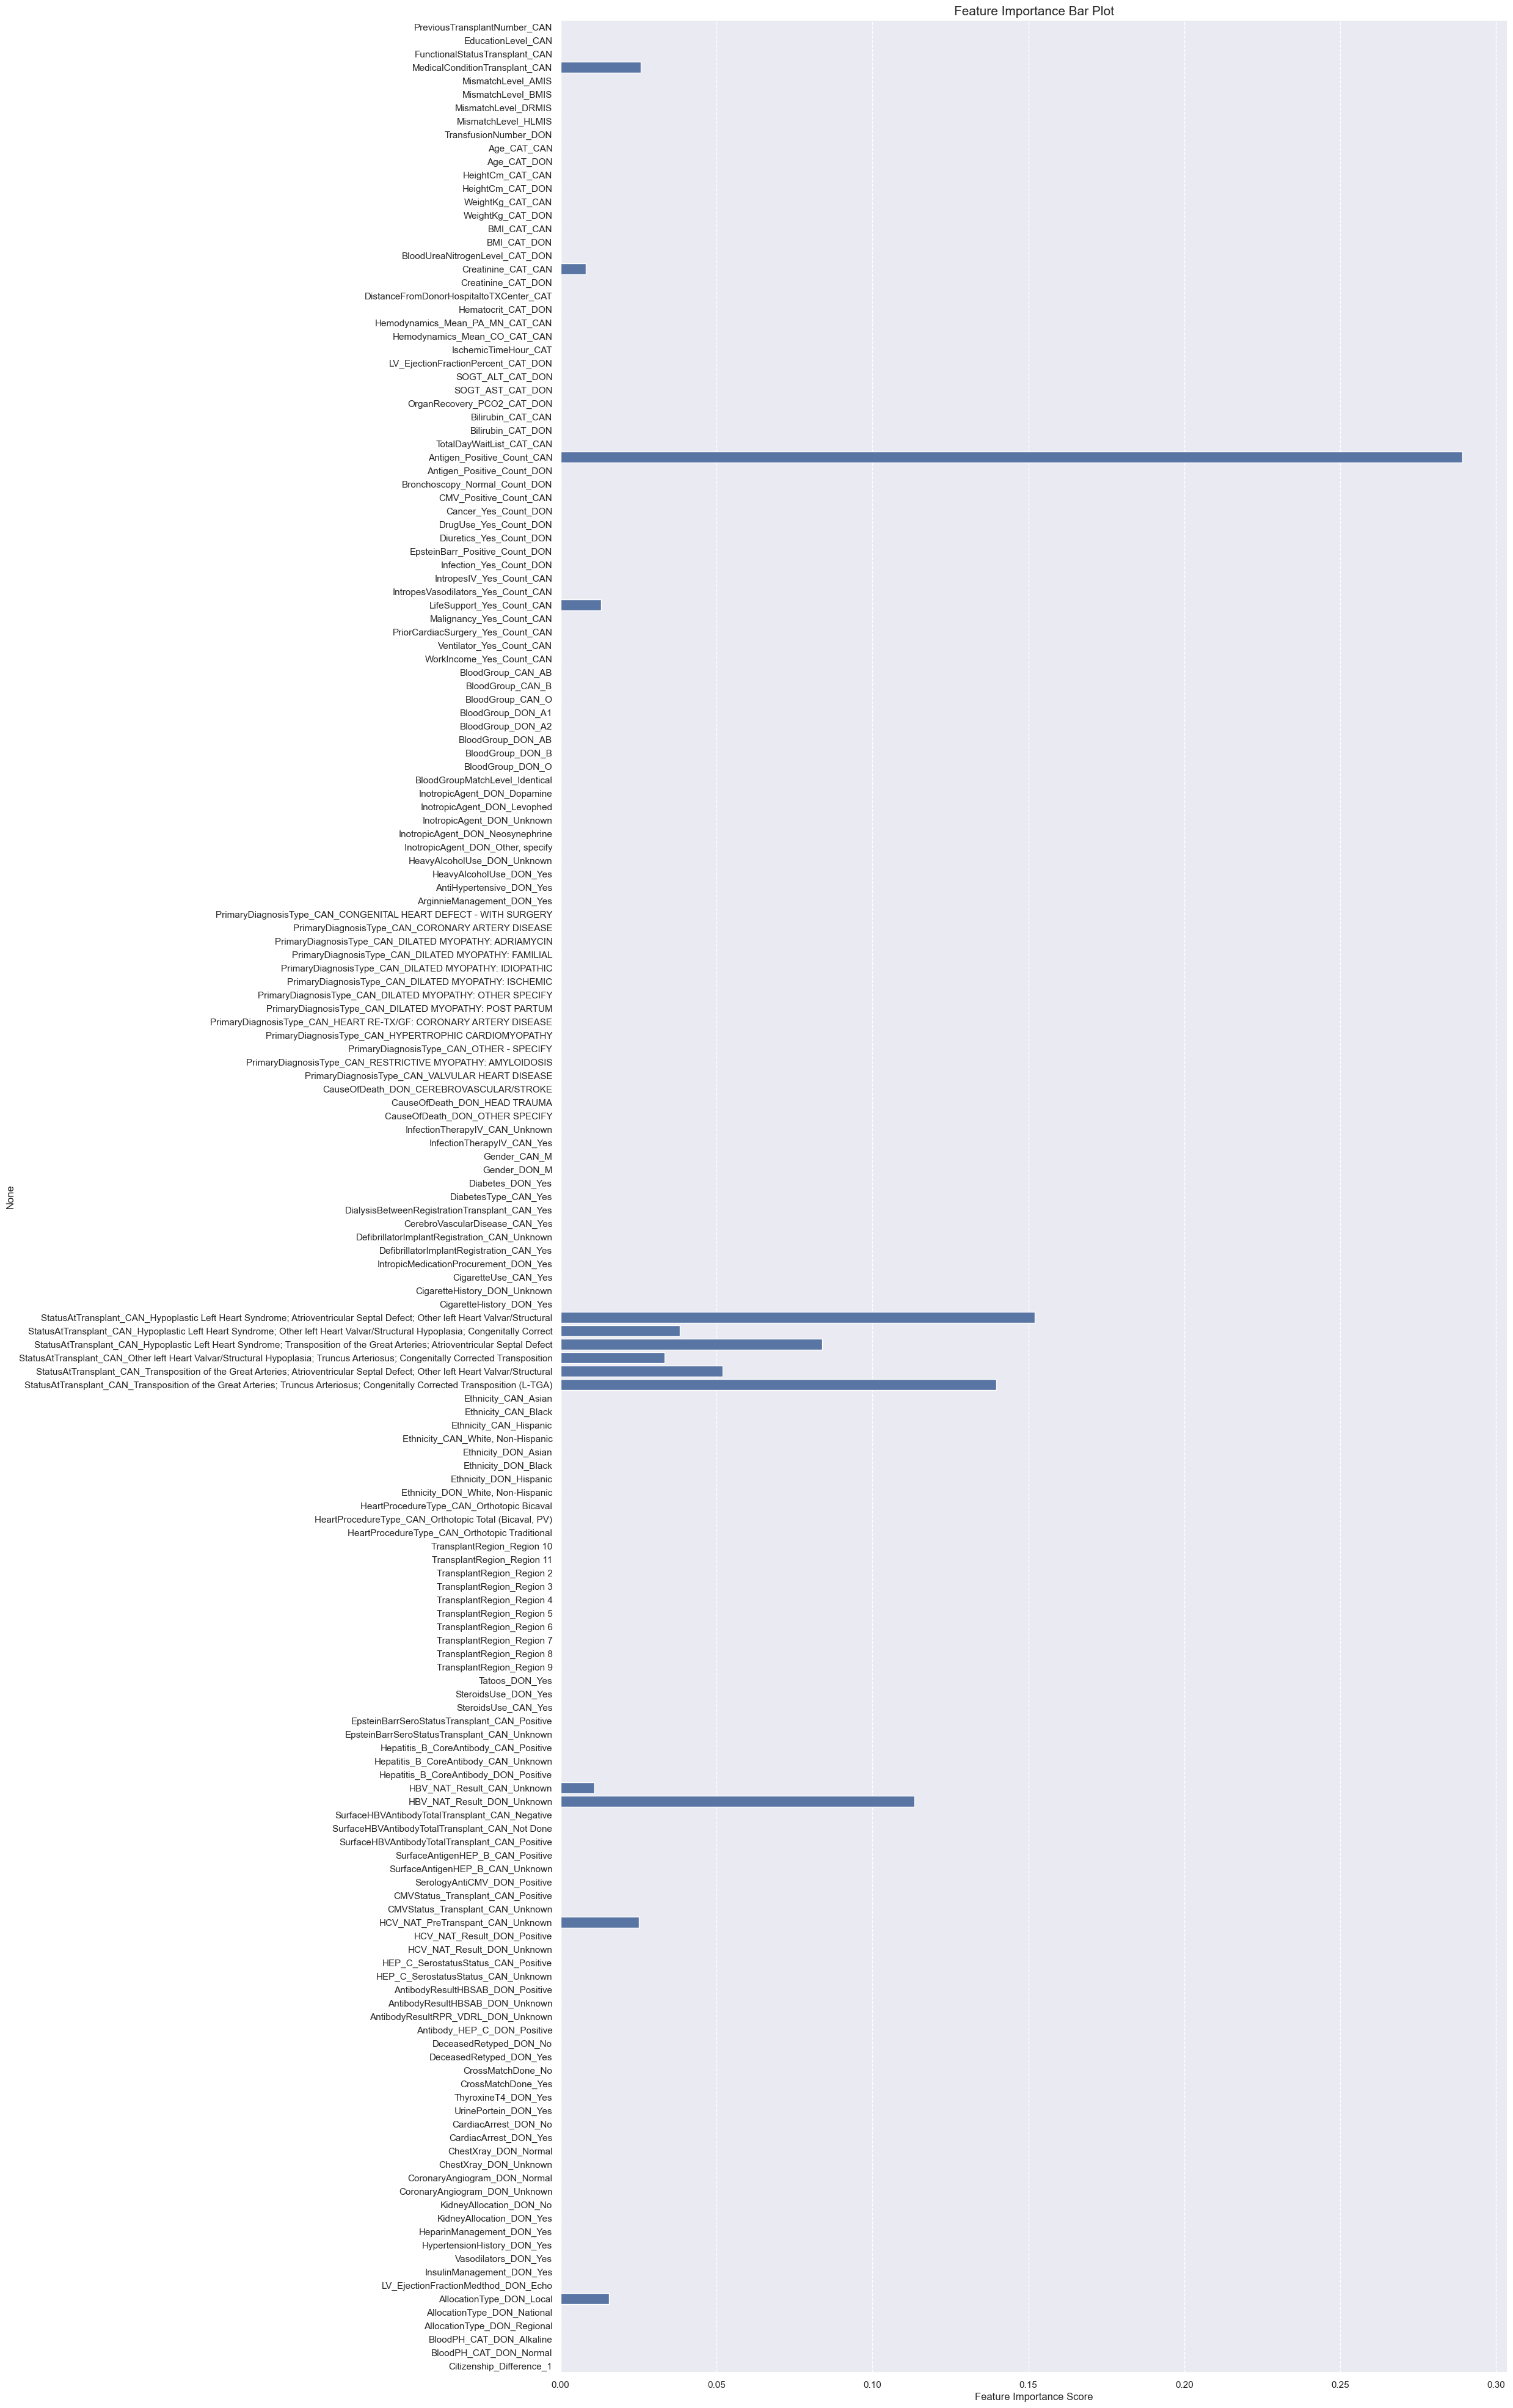

In [36]:
df_ada = umf.plotFeatureImportance(model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [37]:
df_ada.sort_values(by = 'Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
Antigen_Positive_Count_CAN,0.289101
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.152045
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.139650
HBV_NAT_Result_DON_Unknown,0.113432
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,0.083833
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.051973
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.038252
StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition,0.033423
MedicalConditionTransplant_CAN,0.025639
HCV_NAT_PreTranspant_CAN_Unknown,0.025216


### Stacking Classifier
- Both AdaBoost and XGBoost are boosting algorithms, but they have key differences:
    - AdaBoost: Focuses on reducing bias by reweighting misclassified samples, works well with weak learners.
        - AdaBoost → Handles noisy datasets and works well with simpler decision stumps. 
    - XGBoost: A gradient boosting algorithm that minimizes loss efficiently using second-order derivatives and feature importance techniques.
        - XGBoost → Captures complex patterns, handles missing values, and optimizes performance.
    - Random Forest is a bagging-based algorithm that reduces variance and is more robust to noise.

In [38]:
# import library
from sklearn.ensemble import StackingClassifier

# best model
AdaModel = ada_fit.best_estimator_
XGBModel = xgb_fit.best_estimator_

# filt model
AdaModel.fit(X_train, y_train)
XGBModel.fit(X_train, y_train)

# create meta-model
meta_model = LogisticRegression(random_state=RANDOM_STATE)

# create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=[('adaboost', AdaModel), ('xgboost', XGBModel)],
    final_estimator=meta_model,
    cv=5
)

# Fit the stacking ensemble
stack_AdaXgb = stacking_ensemble.fit(X_train, y_train)

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.80      0.97      0.88     10691
        True       0.97      0.75      0.85     10589

    accuracy                           0.86     21280
   macro avg       0.88      0.86      0.86     21280
weighted avg       0.88      0.86      0.86     21280



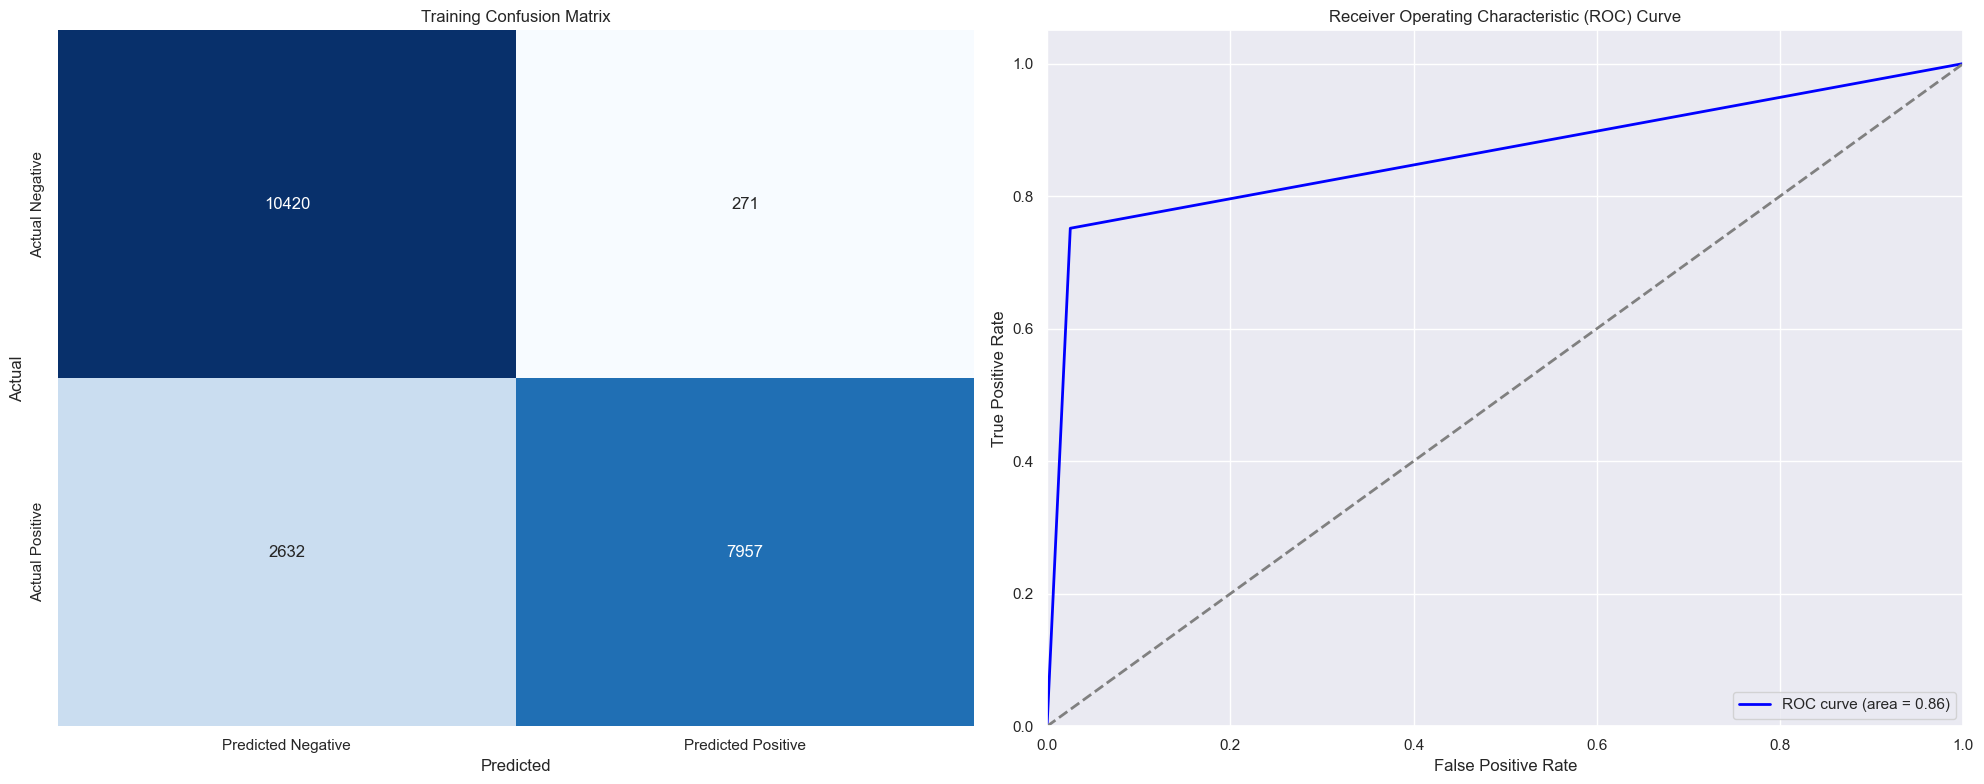

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579
7,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.776880,0.707594,0.759376,0.725245,0.819335,0.845492,0.776543
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.839991,0.718765,0.817201,0.820526,0.946877,0.960060,0.839412
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.844737,0.729505,0.823805,0.824775,0.946105,0.958848,0.844176


In [39]:
# initialize variables
Algorithm = 'Stacking(AdaBoost & XGBoost)'
Desc = 'Stacking - 2011-2016 : Grid Search - Features where variance <= 0.01 removed'
Model = 'stack_AdaXgb'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_AdaXgb, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.96      0.86      2673
        True       0.94      0.74      0.83      2647

    accuracy                           0.85      5320
   macro avg       0.86      0.85      0.84      5320
weighted avg       0.86      0.85      0.85      5320



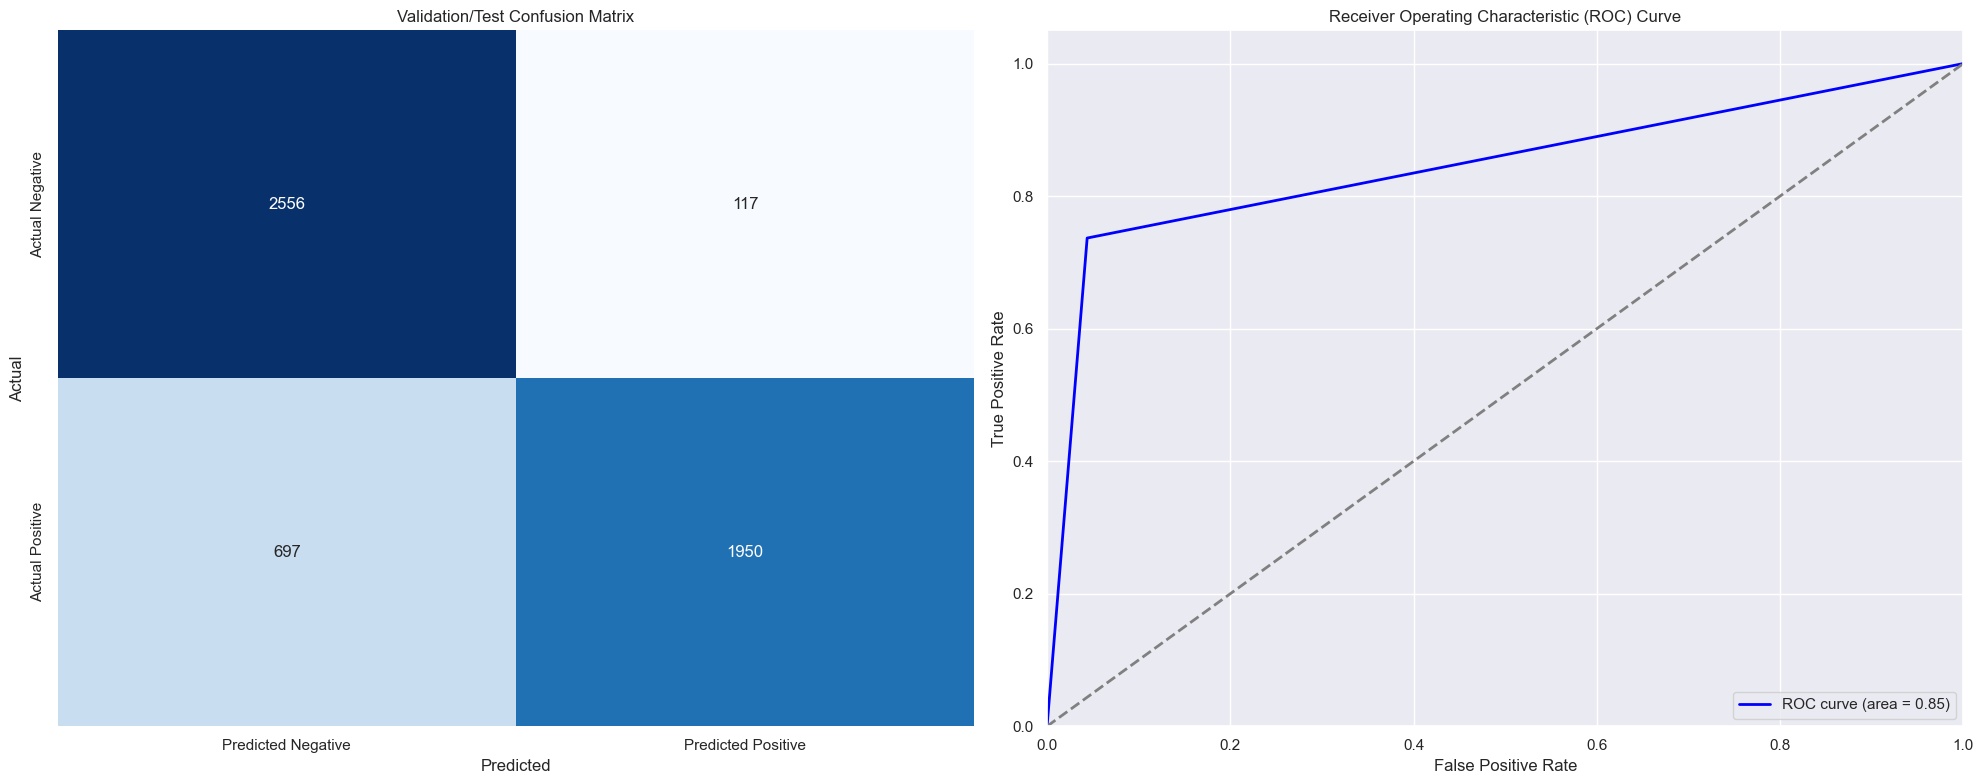

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579
7,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.776880,0.707594,0.759376,0.725245,0.819335,0.845492,0.776543
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.839991,0.718765,0.817201,0.820526,0.946877,0.960060,0.839412
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.844737,0.729505,0.823805,0.824775,0.946105,0.958848,0.844176


In [40]:
# initialize variables
Type = 'Validation/test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_AdaXgb, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

In [41]:
RFCModel = rfc_fit.best_estimator_
XGBModel = xgb_fit.best_estimator_

# filt model
RFCModel.fit(X_train, y_train)
XGBModel.fit(X_train, y_train)

# create meta-model
meta_model = LogisticRegression(random_state=RANDOM_STATE)

# create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=[('randomforest', RFCModel), ('xgboost', XGBModel)],
    final_estimator=meta_model,
    cv=5
)

# fit the stacking ensemble
stack_RfcXgb = stacking_ensemble.fit(X_train, y_train)

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.80      0.97      0.88     10691
        True       0.96      0.76      0.85     10589

    accuracy                           0.87     21280
   macro avg       0.88      0.87      0.87     21280
weighted avg       0.88      0.87      0.87     21280



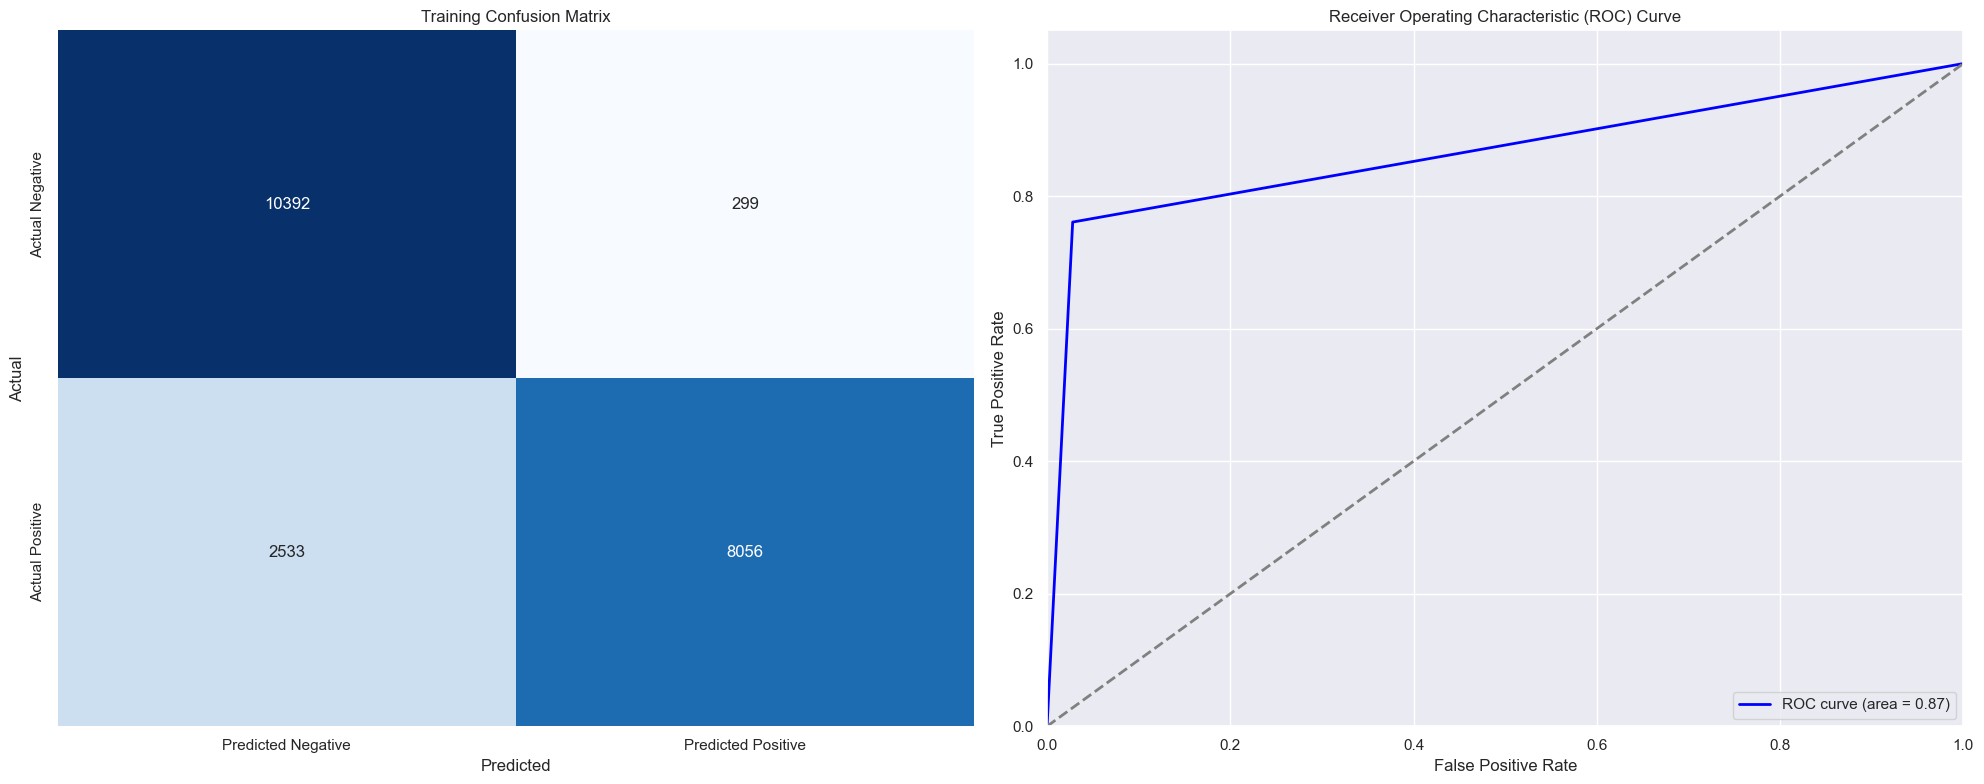

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579
7,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.776880,0.707594,0.759376,0.725245,0.819335,0.845492,0.776543
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.839991,0.718765,0.817201,0.820526,0.946877,0.960060,0.839412
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.844737,0.729505,0.823805,0.824775,0.946105,0.958848,0.844176


In [42]:
# initialize variables
Algorithm = 'Stacking(RandomForest & XGBoost)'
Desc = 'Stacking - 2011-2016: Grid Search - Features where variance <= 0.01 removed'
Model = 'stack_AdaXgb'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_RfcXgb, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.95      0.86      2673
        True       0.94      0.74      0.83      2647

    accuracy                           0.85      5320
   macro avg       0.86      0.85      0.84      5320
weighted avg       0.86      0.85      0.84      5320



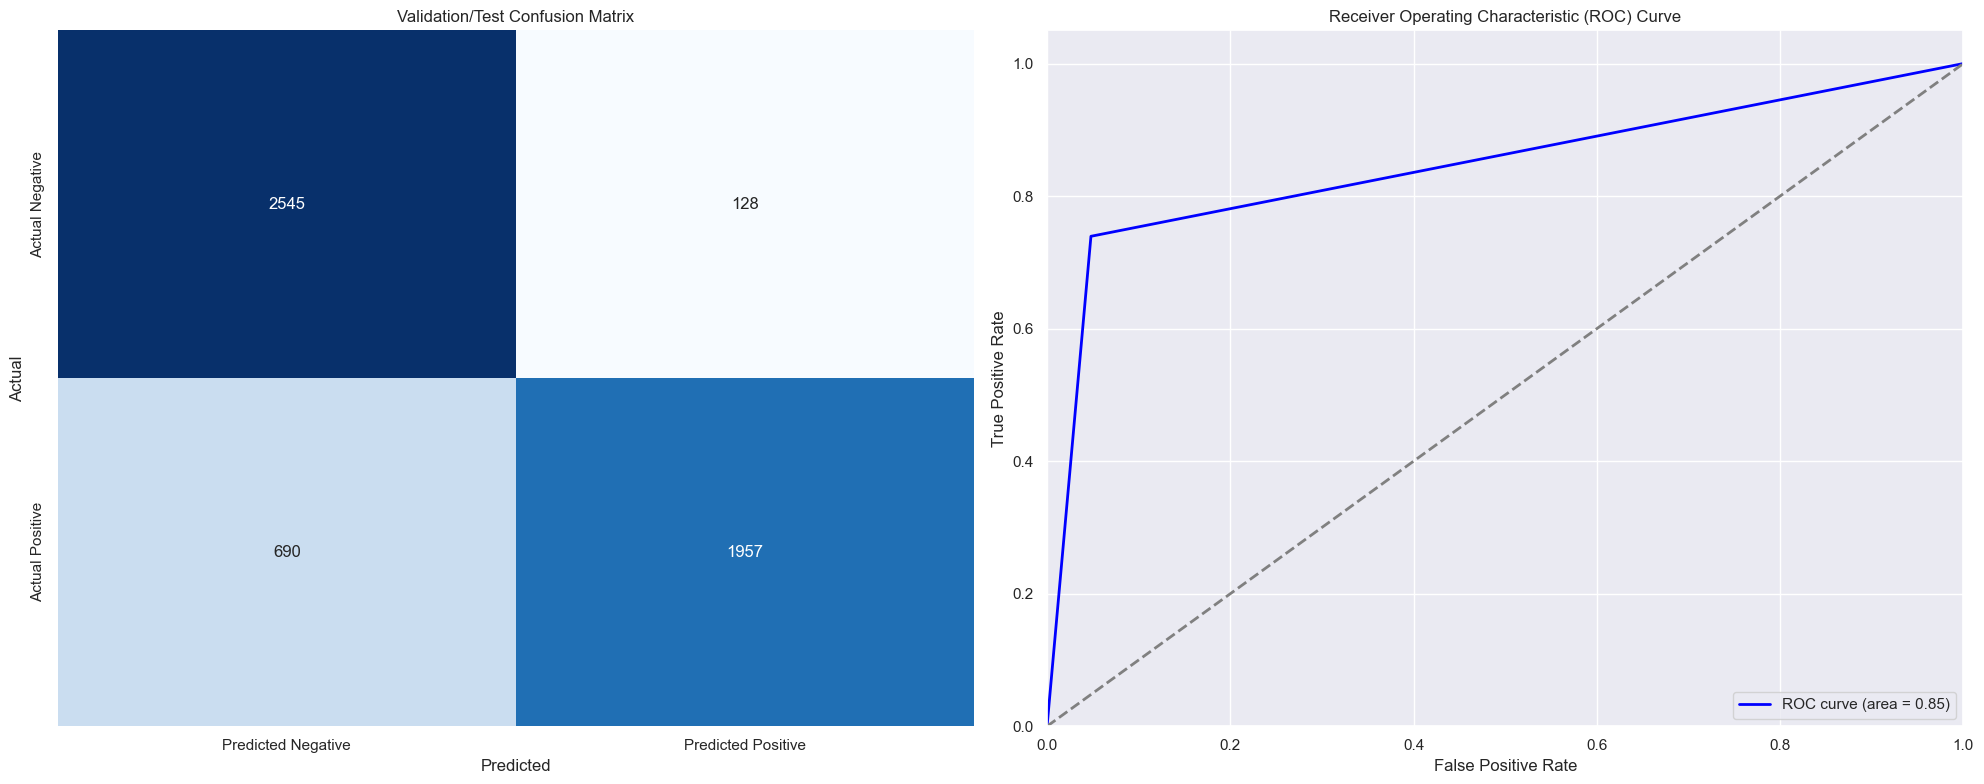

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579
7,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.776880,0.707594,0.759376,0.725245,0.819335,0.845492,0.776543
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.839991,0.718765,0.817201,0.820526,0.946877,0.960060,0.839412
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.844737,0.729505,0.823805,0.824775,0.946105,0.958848,0.844176


In [43]:
# initialize variables
Type = 'Validation/test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_RfcXgb, X_test, y_test, Type, metricDF=df_classfication)
df_classfication

#### Hyper-Paramater Grid Search

In [44]:
# paramater search
parameters = dict(
C = list(np.round(np.linspace(0.01, 1),2))
)
# Base Model
lrc_param = {'max_iter':10000, 'class_weight': class_weight_dict, 'random_state': RANDOM_STATE}

# create meta-model
meta_model = LogisticRegression(**lrc_param)

# CV with grid search for Hyper-Parameter tuning
meta_model_fit = umf.stratified_grid(meta_model, parameters, X_train, y_train, seed=RANDOM_STATE, nJobs=-1, nSplit=5, score='accuracy')

# best model
meta_model = meta_model_fit.best_estimator_

# create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=[('randomforest', RFCModel), ('xgboost', XGBModel)],
    final_estimator=meta_model,
    cv=5
)

# fit the stacking ensemble
stack_GS_RfcXgb = stacking_ensemble.fit(X_train, y_train)

CV accuracy: 0.843 +/- 0.006


/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [45]:
print(stack_GS_RfcXgb)

StackingClassifier(cv=5,
                   estimators=[('randomforest',
                                RandomForestClassifier(class_weight={False: 0.995229632401085,
                                                                     True: 1.0048163188214185},
                                                       max_depth=7,
                                                       min_samples_leaf=8,
                                                       min_samples_split=40,
                                                       random_state=1776)),
                               ('xgboost',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              devi

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.80      0.97      0.88     10691
        True       0.96      0.76      0.85     10589

    accuracy                           0.87     21280
   macro avg       0.88      0.87      0.87     21280
weighted avg       0.88      0.87      0.87     21280



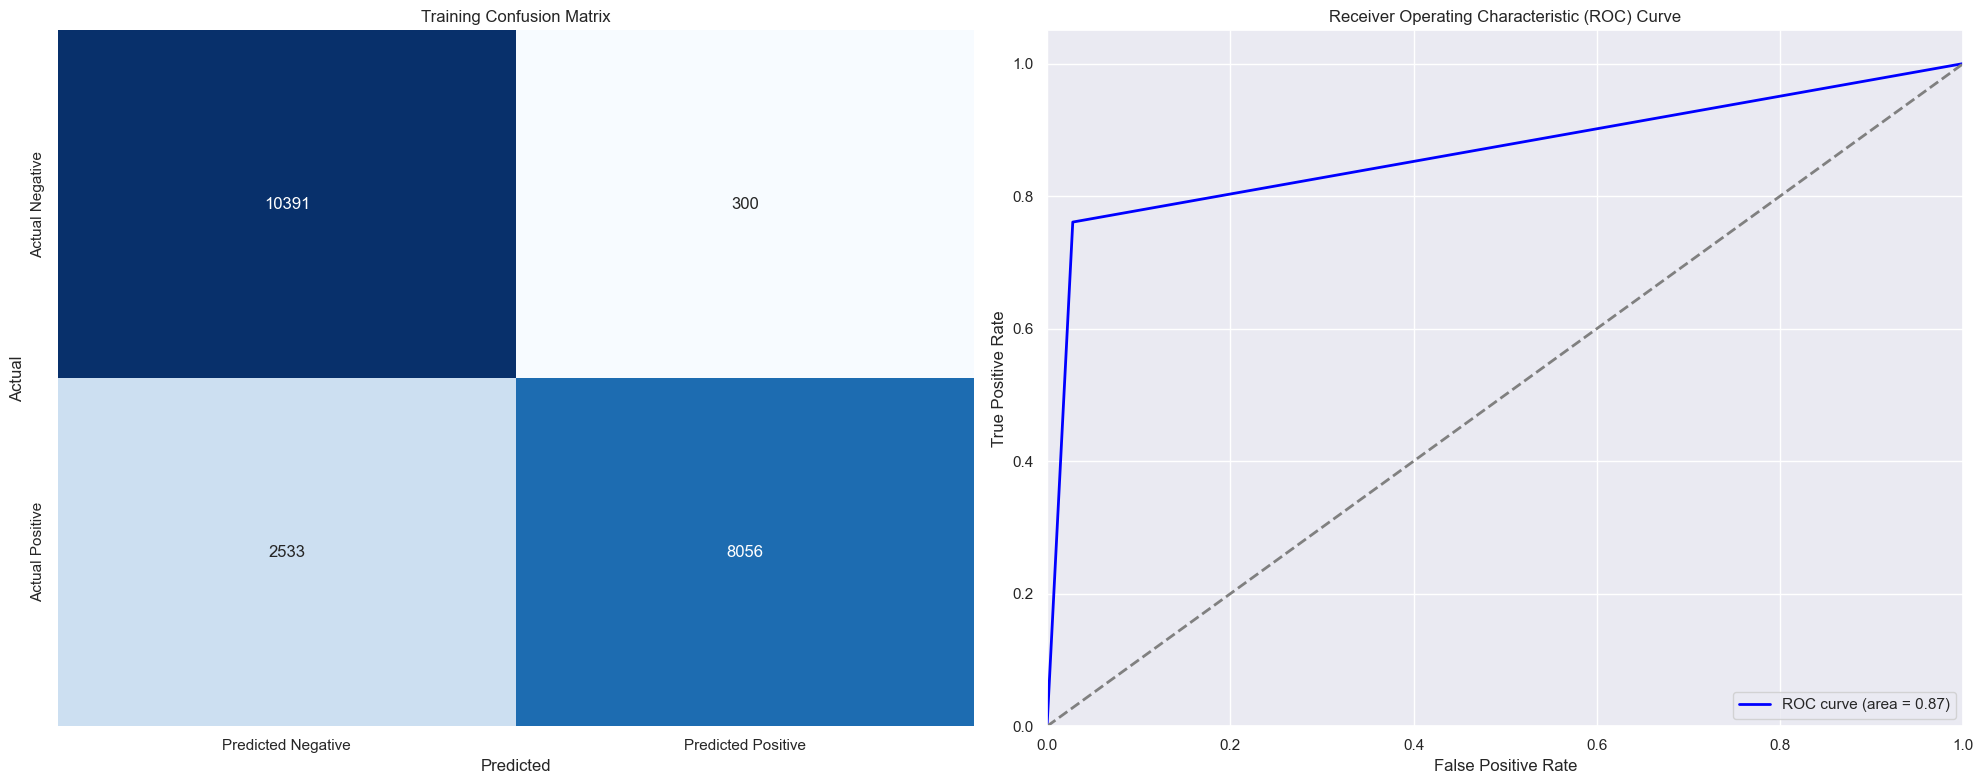

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579
7,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.776880,0.707594,0.759376,0.725245,0.819335,0.845492,0.776543
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.839991,0.718765,0.817201,0.820526,0.946877,0.960060,0.839412
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.844737,0.729505,0.823805,0.824775,0.946105,0.958848,0.844176


In [46]:
# initialize variables
Algorithm = 'Stacking(RandomForest & XGBoost)'
Desc = 'Stacking - 2011-2016 : Grid Search - Features where variance <= 0.01 removed'
Model = 'stack_GS_RfcXgb'
Type = 'Training'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_GS_RfcXgb, X_train, y_train, Type, metricDF=df_classfication)
df_classfication

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.95      0.86      2673
        True       0.94      0.74      0.83      2647

    accuracy                           0.85      5320
   macro avg       0.86      0.85      0.84      5320
weighted avg       0.86      0.85      0.84      5320



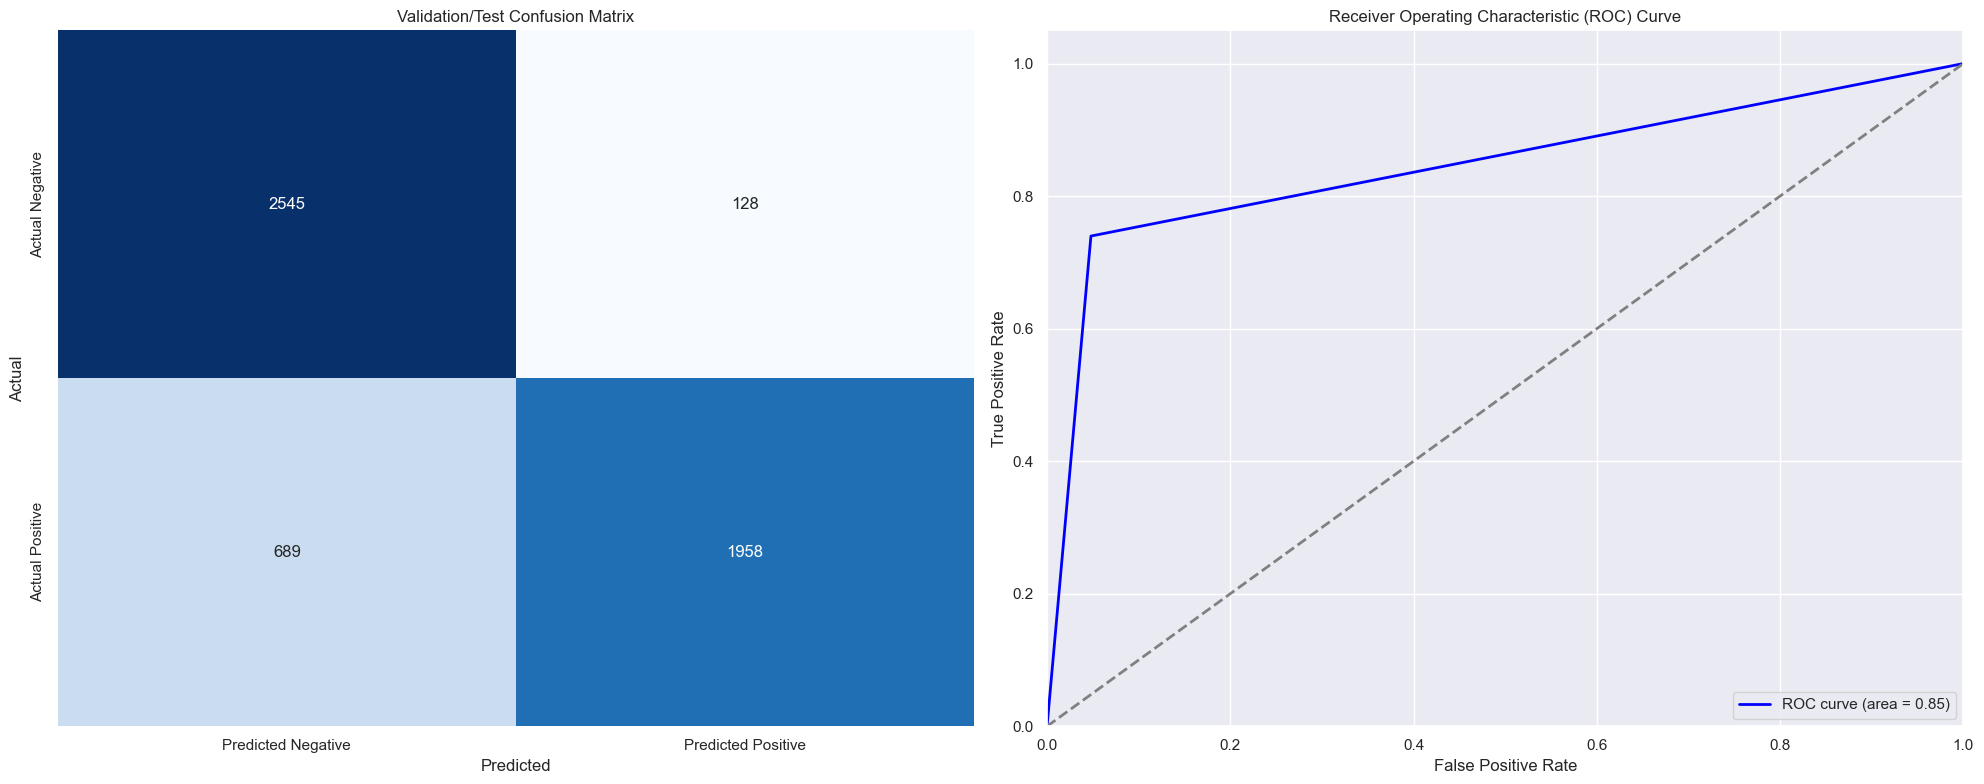

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833036,0.755029,0.818196,0.796061,0.892897,0.910298,0.832664
1,RandomForestClassifier,rfc_fit,RandomForestClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.830451,0.758972,0.816667,0.790746,0.883854,0.901235,0.830103
2,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.845536,0.728303,0.824328,0.826735,0.949520,0.961650,0.844976
3,LogisticRegression,lrc_fit,LogisticRegression - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.850000,0.737816,0.830357,0.830964,0.949441,0.961092,0.849454
4,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.860949,0.736519,0.840545,0.852007,0.978790,0.984192,0.860356
5,XGBClassifier,xgb_fit,XGBClassifier - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.848120,0.725349,0.826162,0.832642,0.959520,0.969697,0.847523
6,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.833882,0.770517,0.821941,0.792802,0.880721,0.896642,0.833579
7,KNN,knn_fit,KNN - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.776880,0.707594,0.759376,0.725245,0.819335,0.845492,0.776543
8,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Training,0.839991,0.718765,0.817201,0.820526,0.946877,0.960060,0.839412
9,AdaBoost,ada_fit,AdaBoost - 2011-2016: Grid Search - Features where variance <= 0.01 removed,Validation/test,0.844737,0.729505,0.823805,0.824775,0.946105,0.958848,0.844176


In [47]:
# initialize variables
Type = 'Validation/test'

# display
df_classfication = umf.ClassificationMatric(Algorithm, Model, Desc, stack_GS_RfcXgb, X_test, y_test, Type, metricDF=df_classfication)
df_classfication